# Phase3A_preprocessing_scientific_v5.6

Scientific-grade preprocessing notebook для **NaPi2b Phase 3A**.


## 1. Зависимости

In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip -q install mdanalysis biopython freesasa pandas numpy scipy networkx tqdm matplotlib seaborn
    !pip -q install torch torch-geometric fair-esm
    !pip -q install yadisk
else:
    print('Running outside Colab: предполагается, что зависимости уже установлены.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.1/270.1 kB 16.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.7/140.7 kB 5.8 MB/s eta 0:00:00


## 2. Импорты

In [ ]:
import os
import gc
import json
import math
import shutil
import warnings
from pathlib import Path
from dataclasses import dataclass, field
from collections import defaultdict
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from torch import Tensor
from torch_geometric.data import HeteroData

import MDAnalysis as mda
from MDAnalysis.analysis import rms, dihedrals
from MDAnalysis.lib.distances import capped_distance, distance_array, calc_bonds, calc_angles

warnings.filterwarnings('ignore')
np.set_printoptions(suppress=True, precision=4)
pd.set_option('display.max_columns', 200)

## 3. Загрузка данных и базовая конфигурация

In [ ]:
import sys, time
import MDAnalysis as mda
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

# ══════════════════════════════════════════════════════════════════
#  КОНСТАНТЫ — определяем первыми, нужны везде ниже
# ══════════════════════════════════════════════════════════════════
PROTEIN_SELECTION = 'protein'
LIPID_SELECTION   = 'resname POPC POPE POPS PSM POPI CHL1 GLPA CER160'
GLYCAN_RESNAMES   = {'BGLC', 'BGLCNA', 'BMAN', 'BGAL', 'BGALNA', 'AFUC', 'ANE5AC'}
FA2G2S2_TEMPLATE  = [
    'BGLCNA', 'BGLCNA', 'BMAN', 'BMAN', 'BMAN', 'BMAN',
    'BGALNA', 'BGALNA', 'AFUC', 'ANE5AC', 'ANE5AC',
]  # PATCH v5: corrected resnames from CHARMM-GUI
CA_SELECTION      = 'protein and name CA'
DEFAULT_GLYCAN_ANCHORS = [295, 308]

AA3_TO_1 = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'HID': 'H',
    'HIE': 'H', 'HIP': 'H', 'HSD': 'H', 'HSE': 'H', 'HSP': 'H',
    'HIE': 'H', 'HIP': 'H', 'ILE': 'I', 'LEU': 'L', 'LYS': 'K',
    'MET': 'M', 'PHE': 'F', 'PRO': 'P', 'SER': 'S', 'THR': 'T',
    'TRP': 'W', 'TYR': 'Y', 'VAL': 'V',
}


# ══════════════════════════════════════════════════════════════════
#  SOURCE = 'yadisk'  — Яндекс Диск (рекомендуется)
#  SOURCE = 'gdrive'  — Google Drive
#  SOURCE = 'local'   — локально вне Colab
# ══════════════════════════════════════════════════════════════════
SOURCE = 'yadisk'

# ──── Токен ───────────────────────────────────────────────────────
YADISK_TOKEN = ''

if IN_COLAB and not YADISK_TOKEN:
    try:
        from google.colab import userdata
        YADISK_TOKEN = userdata.get('YANDEX_TOKEN')
        print('Токен загружен из Colab Secrets.')
    except Exception:
        print('⚠️  YANDEX_TOKEN не найден в Secrets. Вставь токен вручную в YADISK_TOKEN.')

# ──── Пути на Яндекс Диске ────────────────────────────────────────
YADISK_BASE    = 'NAPI2B-ST-GNN'
YADISK_RESULTS = f'{YADISK_BASE}/results/phase3A'

YADISK_PATHS = {
    'normal': {
        'topology':   f'{YADISK_BASE}/results/phase1_md/NORM/03_PRODUCTION/step7_production_10ns.tpr',
        'trajectory': f'{YADISK_BASE}/results/phase1_md/NORM/03_PRODUCTION/step_full_0_30ns.xtc',
        'label': 0,
        'ph': 7.4,
    },
    'tumor': {
        'topology':   f'{YADISK_BASE}/results/phase1_md/TUMOR/03_PRODUCTION/step7_production_10ns.tpr',
        'trajectory': f'{YADISK_BASE}/results/phase1_md/TUMOR/03_PRODUCTION/step_full_0_30ns.xtc',
        'label': 1,
        'ph': 6.8,
    },
}

# ──── Google Drive ─────────────────────────────────────────────────
GDRIVE_BASE = Path('/content/drive/MyDrive/NaPi2b_Phase3A')

# ──── Локальный путь ───────────────────────────────────────────────
LOCAL_BASE = Path.cwd()

# ══════════════════════════════════════════════════════════════════
#  ДИРЕКТОРИИ
# ══════════════════════════════════════════════════════════════════
OUTPUT_DIR = Path('/content/phase3a_outputs_scientific_v2') if IN_COLAB else Path.cwd() / 'phase3a_outputs_scientific_v2'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_CACHE    = OUTPUT_DIR / 'trajectory_cache'
ESM_CACHE_DIR = OUTPUT_DIR / 'esm_cache'
DATA_CACHE.mkdir(exist_ok=True)
ESM_CACHE_DIR.mkdir(exist_ok=True)

# ══════════════════════════════════════════════════════════════════
#  ЯНДЕКС ДИСК: подключение
# ══════════════════════════════════════════════════════════════════
import yadisk as _yadisk

YADISK_AVAILABLE = False

if SOURCE == 'yadisk':
    if not YADISK_TOKEN:
        raise ValueError(
            'YADISK_TOKEN не задан.\n'
            'Добавь токен в Colab Secrets (ключ YANDEX_TOKEN) '
            'или вставь вручную в YADISK_TOKEN.\n'
            'Получить токен: https://yandex.ru/dev/disk/poligon/'
        )
    with _yadisk.Client(token=YADISK_TOKEN) as client:
        if client.check_token():
            YADISK_AVAILABLE = True
            info = client.get_disk_info()
            free_gb = (info.total_space - info.used_space) / 1024**3
            print(f'Яндекс Диск: OK, свободно {free_gb:.1f} GB')
        else:
            raise PermissionError('Токен недействителен. Проверь YADISK_TOKEN.')


def _yadisk_download(yadisk_path: str, dest: Path) -> Path:
    if dest.exists():
        print(f'  [cache] {dest.name}')
        return dest
    dest.parent.mkdir(parents=True, exist_ok=True)
    print(f'  ↓ {yadisk_path.split("/")[-1]}  →  {dest} ...')
    t0 = time.time()
    with _yadisk.Client(token=YADISK_TOKEN) as client:
        client.download(yadisk_path, str(dest))
    elapsed = time.time() - t0
    size_mb = dest.stat().st_size / 1024**2
    print(f'  [ok] {dest.name}  {size_mb:.0f} MB  {elapsed:.1f}s')
    return dest

# ══════════════════════════════════════════════════════════════════
#  СБОРКА CONFIG
# ══════════════════════════════════════════════════════════════════
CONFIG = {}

if SOURCE == 'yadisk':
    for cond, cfg in YADISK_PATHS.items():
        topo_dest = DATA_CACHE / cond / cfg['topology'].split('/')[-1]
        traj_dest = DATA_CACHE / cond / cfg['trajectory'].split('/')[-1]
        _yadisk_download(cfg['topology'],   topo_dest)
        _yadisk_download(cfg['trajectory'], traj_dest)
        CONFIG[cond] = {
            'topology':   topo_dest,
            'trajectory': traj_dest,
            'label': cfg['label'],
            'ph':    cfg['ph'],
        }

elif SOURCE == 'gdrive':
    if IN_COLAB:
        from google.colab import drive
        drive.mount('/content/drive')
    for cond, label, ph in [('normal', 0, 7.4), ('tumor', 1, 6.8)]:
        CONFIG[cond] = {
            'topology':   GDRIVE_BASE / cond / 'step7_production_10ns.tpr',
            'trajectory': GDRIVE_BASE / cond / 'step_full_0_30ns.xtc',
            'label': label,
            'ph':    ph,
        }

elif SOURCE == 'local':
    for cond, label, ph in [('normal', 0, 7.4), ('tumor', 1, 6.8)]:
        CONFIG[cond] = {
            'topology':   LOCAL_BASE / cond / 'step7_production_10ns.tpr',
            'trajectory': LOCAL_BASE / cond / 'step_full_0_30ns.xtc',
            'label': label,
            'ph':    ph,
        }

else:
    raise ValueError(f'Неизвестный SOURCE: {SOURCE!r}')

# ══════════════════════════════════════════════════════════════════
#  ЗАГРУЗКА UNIVERSES
# ══════════════════════════════════════════════════════════════════
UNIVERSES = {}
UNIVERSE_SUMMARY = {}

for condition, cfg in CONFIG.items():
    print(f'[{condition}] загружаю universe...')
    u = mda.Universe(str(cfg['topology']), str(cfg['trajectory']))
    UNIVERSES[condition] = u
    n_frames   = len(u.trajectory)
    n_atoms    = u.atoms.n_atoms
    n_residues = u.select_atoms(PROTEIN_SELECTION).n_residues
    UNIVERSE_SUMMARY[condition] = {
        'condition': condition,
        'label':     cfg['label'],
        'ph':        cfg['ph'],
        'n_frames':  n_frames,
        'n_atoms':   n_atoms,
        'n_residues_protein': n_residues,
        'topology':  str(cfg['topology']),
        'trajectory': str(cfg['trajectory']),
    }
    print(f'  frames={n_frames}  atoms={n_atoms}  protein_residues={n_residues}')

print(f'\nSOURCE     = {SOURCE}')
print(f'OUTPUT_DIR = {OUTPUT_DIR}')
print(f'RESULTS → Яндекс Диск: {YADISK_RESULTS}')
print(f'UNIVERSES  = {list(UNIVERSES.keys())}')


# ══════════════════════════════════════════════════════════════════
#  PATCH v5
# ══════════════════════════════════════════════════════════════════

FA2G2S2_TEMPLATE = [
    'BGLCNA', 'BGLCNA', 'BMAN', 'BMAN', 'BMAN', 'BMAN',
    'BGALNA', 'BGALNA', 'AFUC', 'ANE5AC', 'ANE5AC',
]

BACKBONE_MAX_CA_DIST_A = 4.5

REGIONS_OF_INTEREST = {
    'epitope':      (311, 341),   # FIX v5.2: epitope BEFORE ECD (nested region)
    'ECD':          (234, 361),
    'full_protein': None,
}

print('FA2G2S2_TEMPLATE =', FA2G2S2_TEMPLATE)
print('REGIONS_OF_INTEREST =', REGIONS_OF_INTEREST)
print('BACKBONE_MAX_CA_DIST_A =', BACKBONE_MAX_CA_DIST_A)


Токен загружен из Colab Secrets.
Яндекс Диск: OK, свободно 1776.8 GB
  ↓ step7_production_10ns.tpr  →  /content/phase3a_outputs_scientific_v2/trajectory_cache/normal/step7_production_10ns.tpr ...
  [ok] step7_production_10ns.tpr  16 MB  4.8s
  ↓ step_full_0_30ns.xtc  →  /content/phase3a_outputs_scientific_v2/trajectory_cache/normal/step_full_0_30ns.xtc ...
  [ok] step_full_0_30ns.xtc  5937 MB  315.3s
  ↓ step7_production_10ns.tpr  →  /content/phase3a_outputs_scientific_v2/trajectory_cache/tumor/step7_production_10ns.tpr ...
  [ok] step7_production_10ns.tpr  15 MB  5.6s
  ↓ step_full_0_30ns.xtc  →  /content/phase3a_outputs_scientific_v2/trajectory_cache/tumor/step_full_0_30ns.xtc ...
  [ok] step_full_0_30ns.xtc  5673 MB  283.2s
[normal] загружаю universe...
  frames=3003  atoms=551462  protein_residues=690
[tumor] загружаю universe...
  frames=3003  atoms=526846  protein_residues=690

SOURCE     = yadisk
OUTPUT_DIR = /content/phase3a_outputs_scientific_v2
RESULTS → Яндекс Диск: NAPI2B-S

## 4. Реестр происхождения признаков и семантики рёбер

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  FEATURE_CALC_PARAMS — параметры расчёта взаимодействий
#  Определяем здесь, до загрузки траекторий
#
#  Быстрый прогон (отладка):
#    frame_stride_features  = 10    # ~300 фреймов вместо 3000
#    sasa_frame_stride      = 100   # ~30 фреймов
#    frame_stride_contacts  = 5     # ~600 фреймов
#
#  Финальный прогон:
#    frame_stride_features  = 1
#    sasa_frame_stride      = 50
#    frame_stride_contacts  = 1
# ══════════════════════════════════════════════════════════════════

FEATURE_CALC_PARAMS = {
    # ── Stride ──────────────────────────────────────────────────
    'frame_stride_contacts':          10,    # protein-protein/lipid/glycan контакты
    'frame_stride_features':          10,    # RMSF, DSSP, phi/psi
    'sasa_frame_stride':              50,   # SASA (freesasa, запись PDB)
    'frame_frac':                     0.10, # доля фреймов для FRAME_GRAPHS (Phase3C): 10% → ~300 фреймов при 3003
    'min_contact_frequency':          0.30,

    # ── Водородные связи ─────────────────────────────────────────
    'hbond_distance_cutoff_A':        3.5,
    'hbond_angle_cutoff_deg':         120.0,

    # ── Дисульфидные мостики ─────────────────────────────────────
    'disulfide_sg_cutoff_A':          2.2,

    # ── VdW ──────────────────────────────────────────────────────
    'vdw_distance_min_A':             3.0,
    'vdw_distance_max_A':             4.5,

    # ── Гидрофобные ──────────────────────────────────────────────
    'hydrophobic_cutoff_A':           5.0,

    # ── Ароматика π–π ────────────────────────────────────────────
    'aromatic_pi_centroid_cutoff_A':  7.0,
    'aromatic_parallel_angle_max_deg': 30.0,
    'aromatic_tshape_angle_min_deg':  60.0,
    'aromatic_tshape_angle_max_deg':  120.0,

    # ── Катион–π ─────────────────────────────────────────────────
    'cation_pi_cutoff_A':             6.0,
    'cation_pi_normal_angle_max_deg': 60.0,

    # ── Ионные / солевые мостики ─────────────────────────────────
    'ionic_cutoff_A':                 6.0,
    'salt_bridge_cutoff_A':           4.0,

    # ── Белок–липид / белок–гликан ───────────────────────────────
    'protein_lipid_cutoff_A':         6.0,
    'protein_glycan_cutoff_A':        6.0,
}

print(f'FEATURE_CALC_PARAMS определён: {len(FEATURE_CALC_PARAMS)} параметров')
print(f'  frame_stride_features  = {FEATURE_CALC_PARAMS["frame_stride_features"]}')
print(f'  sasa_frame_stride      = {FEATURE_CALC_PARAMS["sasa_frame_stride"]}')
print(f'  frame_stride_contacts  = {FEATURE_CALC_PARAMS["frame_stride_contacts"]}')
print(f'  frame_frac             = {FEATURE_CALC_PARAMS["frame_frac"]} (→ ~{int(3003 * FEATURE_CALC_PARAMS["frame_frac"])} фреймов при 3003)')


FEATURE_CALC_PARAMS определён: 21 параметров
  frame_stride_features  = 10
  sasa_frame_stride      = 50
  frame_stride_contacts  = 10
  frame_frac             = 0.1 (→ ~300 фреймов при 3003)


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  FEATURE_PROVENANCE — документация признаков узлов
# ══════════════════════════════════════════════════════════════════

FEATURE_PROVENANCE = {
    'protein': {
        'esm2':          {'meaning': 'contextual residue embedding from ESM-2',
                          'units': 'dimensionless', 'source': 'sequence model'},
        'rmsf':          {'meaning': 'root mean square fluctuation of CA atom',
                          'units': 'angstrom', 'source': 'MD trajectory'},
        'sasa':          {'meaning': 'per-residue solvent accessible surface area',
                          'units': 'angstrom^2',
                          'source': 'FreeSASA / Shrake-Rupley-like residue aggregation'},
        'dssp_onehot':   {'meaning': 'secondary structure class (8-state DSSP)',
                          'units': 'one-hot', 'source': 'MDAnalysis DSSP'},
        'phi_psi_sincos': {'meaning': 'sin/cos encoding of backbone phi and psi',
                           'units': 'dimensionless', 'source': 'Ramachandran dihedrals'},
        'tm_relative_z': {'meaning': 'relative Z position within TM span',
                          'units': 'dimensionless', 'source': 'geometry'},
    },
    'lipid': {
        'n_atoms':       {'meaning': 'number of heavy atoms in lipid residue',
                          'units': 'count', 'source': 'topology'},
        'resname_code':  {'meaning': 'integer-encoded lipid resname',
                          'units': 'categorical', 'source': 'topology'},
        'z_com':         {'meaning': 'Z coordinate of lipid center of mass',
                          'units': 'angstrom', 'source': 'geometry'},
    },
    'glycan': {
        'n_monosaccharides': {'meaning': 'total monosaccharide count in template',
                              'units': 'count', 'source': 'FA2G2S2 template'},
        'sialylation_count': {'meaning': 'number of sialic acid residues',
                              'units': 'count', 'source': 'FA2G2S2 template'},
        'fucosylation_count': {'meaning': 'number of fucose residues',
                               'units': 'count', 'source': 'FA2G2S2 template'},
        'anchor_resid':      {'meaning': 'PDB resid of N-glycosylation anchor',
                              'units': 'resid', 'source': 'topology'},
        'anchor_z':          {'meaning': 'Z coordinate of anchor residue COM',
                              'units': 'angstrom', 'source': 'geometry'},
    },
}

# ══════════════════════════════════════════════════════════════════
#  EDGE_SEMANTICS — документация типов рёбер
#  PATCH v5.2: backbone patch применяется ЗДЕСЬ, после определения словаря
# ══════════════════════════════════════════════════════════════════

EDGE_SEMANTICS = {
    'hbond': {
        'criterion': 'distance + angle',
        'distance_A': FEATURE_CALC_PARAMS['hbond_distance_cutoff_A'],
        'angle_deg_min': FEATURE_CALC_PARAMS['hbond_angle_cutoff_deg'],
    },
    'disulfide': {
        'criterion': 'SG-SG distance',
        'distance_A': FEATURE_CALC_PARAMS['disulfide_sg_cutoff_A'],
    },
    'vdw': {
        'criterion': 'heavy-atom distance in window',
        'distance_min_A': FEATURE_CALC_PARAMS['vdw_distance_min_A'],
        'distance_max_A': FEATURE_CALC_PARAMS['vdw_distance_max_A'],
    },
    'hydrophobic': {
        'criterion': 'CB-CB distance, hydrophobic residue pair',
        'distance_A': FEATURE_CALC_PARAMS['hydrophobic_cutoff_A'],
    },
    'aromatic_pi': {
        'criterion': 'ring centroid distance, aromatic pair',
        'distance_A': FEATURE_CALC_PARAMS['aromatic_pi_centroid_cutoff_A'],
    },
    'cation_pi': {
        'criterion': 'cation to aromatic ring centroid',
        'distance_A': FEATURE_CALC_PARAMS['cation_pi_cutoff_A'],
    },
    'ionic': {
        'criterion': 'charged side-chain heavy atom distance',
        'distance_A': FEATURE_CALC_PARAMS['ionic_cutoff_A'],
    },
    'salt_bridge': {
        'criterion': 'donor/acceptor charged atom distance',
        'distance_A': FEATURE_CALC_PARAMS['salt_bridge_cutoff_A'],
    },
    'protein_lipid': {
        'criterion': 'min protein heavy atom to lipid heavy atom',
        'distance_A': FEATURE_CALC_PARAMS['protein_lipid_cutoff_A'],
    },
    'glycan_anchor': {
        'criterion': 'covalent N-glycosylation anchor edge',
        'distance_A': 0.0,
    },
    'protein_glycan': {
        'criterion': 'min protein heavy atom to glycan heavy atom',
        'distance_A': FEATURE_CALC_PARAMS['protein_glycan_cutoff_A'],
    },
}

# ── PATCH v5.2: backbone добавляется ПОСЛЕ определения EDGE_SEMANTICS ────────
EDGE_SEMANTICS['backbone'] = {
    'criterion': 'sequential i→i+1 Cα connectivity with chain-break check',
    'distance_A': BACKBONE_MAX_CA_DIST_A,
}

print('EDGE_SEMANTICS обновлён:', list(EDGE_SEMANTICS.keys()))

# Сохранить провенанс для Phase3B
import json
with open(OUTPUT_DIR / 'edge_semantics.json', 'w') as f:
    json.dump(EDGE_SEMANTICS, f, indent=2, ensure_ascii=False)
print('edge_semantics.json сохранён')

EDGE_SEMANTICS обновлён: ['hbond', 'disulfide', 'vdw', 'hydrophobic', 'aromatic_pi', 'cation_pi', 'ionic', 'salt_bridge', 'protein_lipid', 'glycan_anchor', 'protein_glycan', 'backbone']
edge_semantics.json сохранён


## 5. ESM-2 residue embeddings

In [ ]:
# ESM_CACHE_DIR и AA3_TO_1 определены в ячейке конфига (cell 6)

def extract_protein_sequence(u: mda.Universe) -> Tuple[str, List[int], List[str]]:
    residues = u.select_atoms(PROTEIN_SELECTION).residues
    seq, resid_list, resname_list = [], [], []
    for res in residues:
        aa = AA3_TO_1.get(res.resname)
        if aa is not None:
            seq.append(aa)
            resid_list.append(int(res.resid))
            resname_list.append(res.resname)
    return ''.join(seq), resid_list, resname_list


def compute_esm2_embeddings(sequence: str) -> np.ndarray:
    import esm
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
    model = model.eval().to(device)
    batch_converter = alphabet.get_batch_converter()
    _, _, batch_tokens = batch_converter([('protein', sequence)])
    batch_tokens = batch_tokens.to(device)
    with torch.no_grad():
        results = model(batch_tokens, repr_layers=[33], return_contacts=False)
    reps = results['representations'][33][0, 1:len(sequence)+1]
    return reps.detach().cpu().numpy().astype(np.float32)


def load_or_compute_esm(condition: str, u: mda.Universe) -> Dict[str, Any]:
    sequence, resid_list, resname_list = extract_protein_sequence(u)
    cache_file = ESM_CACHE_DIR / f'{condition}_esm2_embeddings.npy'
    meta_file = ESM_CACHE_DIR / f'{condition}_esm2_meta.json'
    use_cache = False
    if cache_file.exists() and meta_file.exists():
        meta = json.loads(meta_file.read_text())
        if meta.get('sequence') == sequence:
            use_cache = True
    if use_cache:
        embeddings = np.load(cache_file)
    else:
        embeddings = compute_esm2_embeddings(sequence)
        np.save(cache_file, embeddings)
        meta_file.write_text(json.dumps({
            'condition': condition,
            'sequence': sequence,
            'length': len(sequence),
            'embedding_dim': int(embeddings.shape[1])
        }, indent=2))
    return {
        'sequence': sequence,
        'resid_list': resid_list,
        'resname_list': resname_list,
        'embeddings': embeddings
    }


ESM_DATA = {}
for condition, u in UNIVERSES.items():
    ESM_DATA[condition] = load_or_compute_esm(condition, u)
    print(f"[{condition}] ESM shape = {ESM_DATA[condition]['embeddings'].shape}")


Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D-contact-regression.pt
[normal] ESM shape = (690, 1280)
[tumor] ESM shape = (690, 1280)


## 6. Структурные признаки: RMSF, SASA, DSSP, Φ/Ψ, положение в мембране

In [ ]:
import numpy as np
import torch
from tqdm.auto import tqdm
from typing import Tuple, List, Dict, Any
import MDAnalysis as mda
from MDAnalysis.analysis import rms, dihedrals


DSSP_STATES    = ['H', 'B', 'E', 'G', 'I', 'T', 'S', 'C']
DSSP_TO_INDEX  = {s: i for i, s in enumerate(DSSP_STATES)}


def align_feature_to_resids(feature_array: np.ndarray,
                             feature_resids: List[int],
                             target_resids:  List[int]) -> np.ndarray:
    index = {int(r): i for i, r in enumerate(feature_resids)}
    out   = np.zeros((len(target_resids), feature_array.shape[1]), dtype=np.float32)
    for j, resid in enumerate(target_resids):
        if int(resid) in index:
            out[j] = feature_array[index[int(resid)]]
    return out


# ── RMSF ─────────────────────────────────────────────────────────────────────

def compute_rmsf_features(u: mda.Universe,
                           stride: int = 1) -> Tuple[np.ndarray, List[int]]:
    ca = u.select_atoms(CA_SELECTION)
    if len(ca) == 0:
        return np.zeros((0, 1), dtype=np.float32), []
    rmsf_calc = rms.RMSF(ca).run(step=stride)
    return (rmsf_calc.results.rmsf.reshape(-1, 1).astype(np.float32),
            [int(a.resid) for a in ca])


# ── SASA ─────────────────────────────────────────────────────────────────────

def _residue_sasa_fallback_framewise(u: mda.Universe,
                                     frame_stride: int = 50):
    residues = u.select_atoms(PROTEIN_SELECTION).residues
    resids   = [int(r.resid) for r in residues]
    accum    = np.zeros((len(residues),), dtype=np.float64)
    n        = 0
    try:
        import freesasa
        frames  = range(0, len(u.trajectory), max(frame_stride, 1))
        protein = u.select_atoms(PROTEIN_SELECTION)
        tmp_pdb = OUTPUT_DIR / '_tmp_sasa.pdb'
        for fi in tqdm(frames, desc='SASA', leave=False):
            u.trajectory[fi]
            protein.write(str(tmp_pdb))
            try:
                structure = freesasa.Structure(str(tmp_pdb))
                result    = freesasa.calc(structure)
                try:
                    areas = result.residueAreas()
                except AttributeError:
                    areas = freesasa.residueAreas(result, structure)
                by_resid = {}
                for chain_id, chain_map in areas.items():
                    for resid_str, area_obj in chain_map.items():
                        try:
                            rid = int(''.join(filter(str.isdigit, resid_str)))
                            by_resid[rid] = float(area_obj.total)
                        except Exception:
                            pass
                for i, resid in enumerate(resids):
                    accum[i] += by_resid.get(int(resid), 0.0)
                n += 1
            except Exception as e:
                print(f'  frame {fi}: {e}')
        try:
            tmp_pdb.unlink()
        except Exception:
            pass
    except Exception as e:
        print(f'SASA failed: {e}')
    if n == 0:
        return np.zeros((len(residues), 1), dtype=np.float32), resids
    return (accum / n).reshape(-1, 1).astype(np.float32), resids


def compute_sasa_features(u: mda.Universe,
                           frame_stride: int = 50) -> Tuple[np.ndarray, List[int]]:
    return _residue_sasa_fallback_framewise(u, frame_stride=frame_stride)


# ── DSSP ─────────────────────────────────────────────────────────────────────

def classify_secondary_structure_from_angles(phi_deg: float,
                                              psi_deg: float) -> str:
    if np.isnan(phi_deg) or np.isnan(psi_deg):
        return 'C'
    if -160 <= phi_deg <= -20 and  -90 <= psi_deg <=  45:
        return 'H'
    if -180 <= phi_deg <= -40 and   90 <= psi_deg <= 180:
        return 'E'
    if -100 <= phi_deg <= -30 and    0 <= psi_deg <= 100:
        return 'T'
    return 'C'


def compute_dssp_features(u: mda.Universe,
                           stride: int = 1) -> Tuple[np.ndarray, List[int]]:
    residues  = u.select_atoms(PROTEIN_SELECTION).residues
    resids    = [int(r.resid) for r in residues]
    onehot    = np.zeros((len(residues), len(DSSP_STATES)), dtype=np.float32)
    dssp_done = False
    try:
        from MDAnalysis.analysis.dssp import DSSP
        protein_ag = u.select_atoms(PROTEIN_SELECTION)
        dssp       = DSSP(protein_ag).run(step=stride)
        if hasattr(dssp.results, 'dssp'):
            arr = np.asarray(dssp.results.dssp)
            if arr.ndim == 2:
                for col in range(min(arr.shape[1], len(residues))):
                    vals, counts = np.unique(arr[:, col], return_counts=True)
                    state = vals[np.argmax(counts)]
                    state = state if state in DSSP_TO_INDEX else 'C'
                    onehot[col, DSSP_TO_INDEX[state]] = 1.0
                dssp_done = True
    except Exception as e:
        print(f'DSSP primary path unavailable: {e}')
    if not dssp_done:
        try:
            rama   = dihedrals.Ramachandran(residues).run(step=stride)
            angles = rama.results.angles
            if angles.ndim == 3:
                mean_angles = np.nanmean(angles, axis=0)
                for i, (phi, psi) in enumerate(mean_angles):
                    state = classify_secondary_structure_from_angles(phi, psi)
                    onehot[i, DSSP_TO_INDEX[state]] = 1.0
            else:
                onehot[:, DSSP_TO_INDEX['C']] = 1.0
        except Exception:
            onehot[:, DSSP_TO_INDEX['C']] = 1.0
    return onehot, resids


# ── Phi / Psi ─────────────────────────────────────────────────────────────────

def compute_phi_psi_features(u: mda.Universe,
                              stride: int = 1) -> Tuple[np.ndarray, List[int]]:
    residues = u.select_atoms(PROTEIN_SELECTION).residues
    out      = np.zeros((len(residues), 4), dtype=np.float32)
    resids   = [int(r.resid) for r in residues]
    try:
        rama   = dihedrals.Ramachandran(residues).run(step=stride)
        angles = rama.results.angles
        if angles.ndim == 3:
            mean_angles = np.nanmean(angles, axis=0)
            phi = mean_angles[:, 0]
            psi = mean_angles[:, 1]
            out[:, 0] = np.nan_to_num(np.sin(np.deg2rad(phi)), nan=0.0)
            out[:, 1] = np.nan_to_num(np.cos(np.deg2rad(phi)), nan=0.0)
            out[:, 2] = np.nan_to_num(np.sin(np.deg2rad(psi)), nan=0.0)
            out[:, 3] = np.nan_to_num(np.cos(np.deg2rad(psi)), nan=0.0)
    except Exception as e:
        print(f'Phi/Psi fallback: {e}')
    return out, resids


# ── TM relative Z ─────────────────────────────────────────────────────────────

def compute_tm_relative_z(u: mda.Universe) -> Tuple[np.ndarray, List[int]]:
    residues = u.select_atoms(PROTEIN_SELECTION).residues
    resids   = [int(r.resid) for r in residues]
    vals     = np.zeros((len(residues), 1), dtype=np.float32)
    try:
        refz = u.select_atoms(PROTEIN_SELECTION).center_of_mass()[2]
        for i, res in enumerate(residues):
            vals[i, 0] = float(res.atoms.center_of_mass()[2] - refz)
    except Exception:
        pass
    return vals, resids


# ── Bundle ────────────────────────────────────────────────────────────────────

def build_structural_feature_bundle(condition: str,
                                     u: mda.Universe) -> Dict[str, np.ndarray]:
    """
    Все тяжёлые расчёты используют stride из FEATURE_CALC_PARAMS:
      frame_stride_features — RMSF, DSSP, phi/psi
      sasa_frame_stride     — SASA (freesasa, запись PDB на каждый фрейм)

    Быстрый прогон: frame_stride_features=10, sasa_frame_stride=100
    Финальный:      frame_stride_features=1,  sasa_frame_stride=50
    """
    target       = ESM_DATA[condition]['resid_list']
    stride_feats = FEATURE_CALC_PARAMS['frame_stride_features']
    stride_sasa  = FEATURE_CALC_PARAMS['sasa_frame_stride']

    n_frames  = len(u.trajectory)
    eff_feats = max(1, n_frames // stride_feats) if stride_feats > 1 else n_frames
    eff_sasa  = max(1, n_frames // stride_sasa)
    print(f'[{condition}] trajectory: {n_frames} frames | '
          f'RMSF/DSSP/phi-psi: ~{eff_feats} (stride={stride_feats}) | '
          f'SASA: ~{eff_sasa} (stride={stride_sasa})')

    rmsf_arr, rmsf_resids = compute_rmsf_features(u,  stride=stride_feats)
    sasa_arr, sasa_resids = compute_sasa_features(u,  frame_stride=stride_sasa)
    dssp_arr, dssp_resids = compute_dssp_features(u,  stride=stride_feats)
    pp_arr,   pp_resids   = compute_phi_psi_features(u, stride=stride_feats)
    tmz_arr,  tmz_resids  = compute_tm_relative_z(u)

    return {
        'rmsf':          align_feature_to_resids(rmsf_arr, rmsf_resids, target),
        'sasa':          align_feature_to_resids(sasa_arr, sasa_resids, target),
        'dssp':          align_feature_to_resids(dssp_arr, dssp_resids, target),
        'phi_psi':       align_feature_to_resids(pp_arr,   pp_resids,   target),
        'tm_relative_z': align_feature_to_resids(tmz_arr,  tmz_resids,  target),
    }


# ── Запуск ────────────────────────────────────────────────────────────────────

STRUCTURAL_FEATURES = {}
for condition, u in UNIVERSES.items():
    STRUCTURAL_FEATURES[condition] = build_structural_feature_bundle(condition, u)
    print(condition, {k: v.shape for k, v in STRUCTURAL_FEATURES[condition].items()})

[normal] trajectory: 3003 frames | RMSF/DSSP/phi-psi: ~300 (stride=10) | SASA: ~60 (stride=50)


SASA:   0%|          | 0/61 [00:00<?, ?it/s]

Phi/Psi fallback: could not broadcast input array from shape (688,) into shape (690,)
normal {'rmsf': (690, 1), 'sasa': (690, 1), 'dssp': (690, 8), 'phi_psi': (690, 4), 'tm_relative_z': (690, 1)}
[tumor] trajectory: 3003 frames | RMSF/DSSP/phi-psi: ~300 (stride=10) | SASA: ~60 (stride=50)


SASA:   0%|          | 0/61 [00:00<?, ?it/s]

Phi/Psi fallback: could not broadcast input array from shape (688,) into shape (690,)
tumor {'rmsf': (690, 1), 'sasa': (690, 1), 'dssp': (690, 8), 'phi_psi': (690, 4), 'tm_relative_z': (690, 1)}


## 7. Геометрия взаимодействий

In [ ]:
import numpy as np
import torch
import pandas as pd
import MDAnalysis as mda
from tqdm.auto import tqdm
from typing import Tuple, List, Dict
from dataclasses import dataclass, field
from collections import defaultdict
from torch import Tensor
from MDAnalysis.lib.distances import capped_distance, calc_angles

# ── Константы ────────────────────────────────────────────────────────────────

RELATION_TYPES = [
    ('protein', 'backbone',       'protein'),   # PATCH v5
    ('protein', 'hbond',          'protein'),
    ('protein', 'disulfide',      'protein'),
    ('protein', 'vdw',            'protein'),
    ('protein', 'hydrophobic',    'protein'),
    ('protein', 'aromatic_pi',    'protein'),
    ('protein', 'cation_pi',      'protein'),
    ('protein', 'ionic',          'protein'),
    ('protein', 'salt_bridge',    'protein'),
    ('protein', 'protein_lipid',  'lipid'),
    ('protein', 'glycan_anchor',  'glycan'),
    ('protein', 'protein_glycan', 'glycan'),
]

EDGE_ATTR_NAMES     = ['contact_freq', 'mean_dist', 'std_dist']
HYDROPHOBIC_RESNAMES = {'ALA', 'VAL', 'ILE', 'LEU', 'MET', 'PHE', 'TRP', 'PRO'}
AROMATIC_RESNAMES    = {'PHE', 'TYR', 'TRP', 'HIS', 'HID', 'HIE', 'HIP', 'HSD', 'HSE', 'HSP'}
CATIONIC_RESNAMES    = {'LYS', 'ARG', 'HIS', 'HID', 'HIE', 'HIP', 'HSD', 'HSE', 'HSP'}
ACIDIC_RESNAMES      = {'ASP', 'GLU'}
BASIC_RESNAMES       = {'LYS', 'ARG'}

# ── Аккумуляторы ─────────────────────────────────────────────────────────────

@dataclass
class EdgeAccumulator:
    count: int = 0
    distances: List[float] = field(default_factory=list)


class InteractionAccumulator:
    def __init__(self):
        self.store = defaultdict(EdgeAccumulator)

    def add(self, i: int, j: int, d: float):
        key = (int(i), int(j))
        self.store[key].count += 1
        self.store[key].distances.append(float(d))

    def finalize(self, n_frames: int, min_freq: float = 0.3) -> Tuple[Tensor, Tensor]:
        edge_pairs, edge_attr = [], []
        for (i, j), acc in self.store.items():
            freq = acc.count / max(n_frames, 1)
            if freq >= min_freq:
                arr = np.asarray(acc.distances, dtype=np.float32)
                edge_pairs.append([i, j])
                edge_attr.append([
                    float(freq),
                    float(arr.mean()),
                    float(arr.std(ddof=0) if len(arr) > 1 else 0.0)
                ])
        if len(edge_pairs) == 0:
            return torch.empty((2, 0), dtype=torch.long), torch.empty((0, 3), dtype=torch.float32)
        return (torch.tensor(edge_pairs, dtype=torch.long).T.contiguous(),
                torch.tensor(edge_attr, dtype=torch.float32))

# ── Вспомогательные функции ──────────────────────────────────────────────────

def get_residue_metadata(condition: str) -> pd.DataFrame:
    return pd.DataFrame({
        'resid':   ESM_DATA[condition]['resid_list'],
        'resname': ESM_DATA[condition]['resname_list'],
        'index':   list(range(len(ESM_DATA[condition]['resid_list'])))
    })


def _safe_unit_vector(v):
    n = np.linalg.norm(v)
    return v / n if n > 0 else None


def _angle_between_normals_deg(n1, n2):
    if n1 is None or n2 is None:
        return None
    return float(np.degrees(np.arccos(np.clip(np.abs(np.dot(n1, n2)), -1.0, 1.0))))


def _ring_sel(resid: int, resname: str) -> str:
    mapping = {
        'PHE': 'name CG CD1 CD2 CE1 CE2 CZ',
        'TYR': 'name CG CD1 CD2 CE1 CE2 CZ',
        'TRP': 'name CD2 CE2 CE3 CZ2 CZ3 CH2',
        'HIS': 'name CG ND1 CD2 CE1 NE2',
        'HID': 'name CG ND1 CD2 CE1 NE2',
        'HIE': 'name CG ND1 CD2 CE1 NE2',
        'HIP': 'name CG ND1 CD2 CE1 NE2',
        'HSD': 'name CG ND1 CD2 CE1 NE2',
        'HSE': 'name CG ND1 CD2 CE1 NE2',
        'HSP': 'name CG ND1 CD2 CE1 NE2',
    }
    return f'protein and resid {resid} and ({mapping.get(resname, "name CA")})'


def _ring_centroid_normal(ag):
    """Centroid и нормаль к плоскости кольца из AtomGroup."""
    if len(ag) < 3:
        return None, None
    pos = ag.positions.astype(np.float64)
    centroid = pos.mean(axis=0)
    normal   = _safe_unit_vector(np.cross(pos[1] - pos[0], pos[2] - pos[0]))
    return centroid, normal

# ── Построение кэша atom groups (вызывается один раз) ────────────────────────

def _build_atom_cache(u: mda.Universe, meta: pd.DataFrame) -> dict:
    cache = {}

    cache['donor']    = u.select_atoms('protein and (name N NE NH1 NH2 ND1 ND2 OG OG1 OH NZ NE2)')
    cache['hydrogen'] = u.select_atoms('protein and name H*')
    cache['acceptor'] = u.select_atoms('protein and (name O OD1 OD2 OE1 OE2 OG OG1 OH SD NE2)')
    cache['sg']       = u.select_atoms('protein and resname CYS CYX and name SG')
    cache['heavy']    = u.select_atoms('protein and not name H*')

    # hydrogens grouped by resid
    h_by_resid = defaultdict(list)
    for h in cache['hydrogen']:
        h_by_resid[int(h.resid)].append(h)
    cache['h_by_resid'] = h_by_resid

    # Сайдчейны гидрофобных остатков
    hydro_resids = meta[meta['resname'].isin(HYDROPHOBIC_RESNAMES)]['resid'].tolist()
    cache['hydro_resids'] = hydro_resids
    cache['sidechain_ag'] = {}
    for r in hydro_resids:
        ag = u.select_atoms(f'protein and resid {r} and not backbone and not name H*')
        if len(ag) == 0:
            ag = u.select_atoms(f'protein and resid {r} and not name H*')
        cache['sidechain_ag'][int(r)] = ag

    # Кольца ароматических остатков
    aro_rows = meta[meta['resname'].isin(AROMATIC_RESNAMES)][['resid', 'resname']].to_dict('records')
    cache['aro_rows'] = aro_rows
    cache['ring_ag']  = {int(row['resid']): u.select_atoms(_ring_sel(int(row['resid']), row['resname']))
                         for row in aro_rows}

    # Катионные группы
    cation_rows = meta[meta['resname'].isin(CATIONIC_RESNAMES)][['resid', 'resname']].to_dict('records')
    cache['cation_rows'] = cation_rows
    cache['pos_ag'] = {int(row['resid']): u.select_atoms(
                           f"protein and resid {int(row['resid'])} and name NZ NH1 NH2 NE ND1 NE2")
                       for row in cation_rows}

    # Кислотные / основные группы
    acid_rows = meta[meta['resname'].isin(ACIDIC_RESNAMES)][['resid', 'resname']].to_dict('records')
    base_rows = meta[meta['resname'].isin(BASIC_RESNAMES)][['resid', 'resname']].to_dict('records')
    cache['acid_rows'] = acid_rows
    cache['base_rows'] = base_rows
    cache['neg_ag']      = {int(row['resid']): u.select_atoms(
                                f"protein and resid {int(row['resid'])} and name OD1 OD2 OE1 OE2")
                            for row in acid_rows}
    cache['base_pos_ag'] = {int(row['resid']): u.select_atoms(
                                f"protein and resid {int(row['resid'])} and name NZ NH1 NH2 NE ND1 NE2")
                            for row in base_rows}
    return cache

# ── Детекторы взаимодействий (per-frame, без select_atoms) ───────────────────

def _frame_hbond(cache, stores, rmap, p):
    da, aa = cache['donor'], cache['acceptor']
    if len(da) == 0 or len(aa) == 0:
        return
    pairs, dd = capped_distance(da.positions, aa.positions,
                                max_cutoff=p['hbond_distance_cutoff_A'], return_distances=True)
    h_by_resid = cache['h_by_resid']
    acc = stores['hbond']
    for (i, j), d in zip(pairs, dd):
        donor    = da[int(i)]
        acceptor = aa[int(j)]
        rd, ra   = int(donor.resid), int(acceptor.resid)
        if rd == ra or rd not in rmap or ra not in rmap:
            continue
        for h in h_by_resid.get(rd, []):
            try:
                angle = np.degrees(calc_angles(donor.position, h.position, acceptor.position))
                if np.isfinite(angle) and angle >= p['hbond_angle_cutoff_deg']:
                    acc.add(rmap[rd], rmap[ra], float(d))
                    break
            except Exception:
                continue


def _frame_disulfide(cache, stores, rmap, p):
    sg = cache['sg']
    if len(sg) < 2:
        return
    pairs, dd = capped_distance(sg.positions, sg.positions,
                                max_cutoff=p['disulfide_sg_cutoff_A'], return_distances=True)
    acc = stores['disulfide']
    for (i, j), d in zip(pairs, dd):
        ai, aj = sg[int(i)], sg[int(j)]
        if ai.index >= aj.index:
            continue
        ri, rj = int(ai.resid), int(aj.resid)
        if ri != rj and ri in rmap and rj in rmap:
            acc.add(rmap[ri], rmap[rj], float(d))
            acc.add(rmap[rj], rmap[ri], float(d))


def _frame_vdw(cache, stores, rmap, p):
    heavy = cache['heavy']
    if len(heavy) == 0:
        return
    pairs, dd = capped_distance(heavy.positions, heavy.positions,
                                max_cutoff=p['vdw_distance_max_A'], return_distances=True)
    vmin = p['vdw_distance_min_A']
    acc  = stores['vdw']
    for (i, j), d in zip(pairs, dd):
        if i >= j or d < vmin:
            continue
        ri, rj = int(heavy[i].resid), int(heavy[j].resid)
        if ri != rj and ri in rmap and rj in rmap:
            acc.add(rmap[ri], rmap[rj], float(d))
            acc.add(rmap[rj], rmap[ri], float(d))


def _frame_hydrophobic(cache, stores, rmap, p):
    coords, resids = [], []
    for r in cache['hydro_resids']:
        ag = cache['sidechain_ag'][int(r)]
        if len(ag):
            coords.append(ag.center_of_mass())
            resids.append(int(r))
    if len(coords) < 2:
        return
    pairs, dd = capped_distance(np.asarray(coords), np.asarray(coords),
                                max_cutoff=p['hydrophobic_cutoff_A'], return_distances=True)
    acc = stores['hydrophobic']
    for (i, j), d in zip(pairs, dd):
        ri, rj = resids[int(i)], resids[int(j)]
        if ri < rj:
            acc.add(rmap[ri], rmap[rj], float(d))
            acc.add(rmap[rj], rmap[ri], float(d))


def _get_ring_data(cache):
    ring_data = []
    for row in cache['aro_rows']:
        ag = cache['ring_ag'][int(row['resid'])]
        centroid, normal = _ring_centroid_normal(ag)
        if centroid is not None and normal is not None:
            ring_data.append((int(row['resid']), centroid, normal))
    return ring_data


def _frame_aromatic_pi(cache, stores, rmap, p):
    ring_data = _get_ring_data(cache)
    if len(ring_data) < 2:
        return
    coords  = np.asarray([x[1] for x in ring_data])
    resids  = [x[0] for x in ring_data]
    normals = [x[2] for x in ring_data]
    pairs, dd = capped_distance(coords, coords,
                                max_cutoff=p['aromatic_pi_centroid_cutoff_A'], return_distances=True)
    acc = stores['aromatic_pi']
    for (i, j), d in zip(pairs, dd):
        if int(i) >= int(j):
            continue
        angle = _angle_between_normals_deg(normals[int(i)], normals[int(j)])
        if angle is None:
            continue
        if (angle <= p['aromatic_parallel_angle_max_deg'] or
                p['aromatic_tshape_angle_min_deg'] <= angle <= p['aromatic_tshape_angle_max_deg']):
            ri, rj = resids[int(i)], resids[int(j)]
            acc.add(rmap[ri], rmap[rj], float(d))
            acc.add(rmap[rj], rmap[ri], float(d))


def _frame_cation_pi(cache, stores, rmap, p):
    cations = [(int(row['resid']), cache['pos_ag'][int(row['resid'])].center_of_mass())
               for row in cache['cation_rows']
               if len(cache['pos_ag'][int(row['resid'])]) > 0]
    rings   = _get_ring_data(cache)
    if not cations or not rings:
        return
    cat_coords  = np.asarray([x[1] for x in cations])
    ring_coords = np.asarray([x[1] for x in rings])
    pairs, dd   = capped_distance(cat_coords, ring_coords,
                                  max_cutoff=p['cation_pi_cutoff_A'], return_distances=True)
    acc = stores['cation_pi']
    for (i, j), d in zip(pairs, dd):
        cat_resid,  cat_pos                    = cations[int(i)]
        ring_resid, ring_centroid, ring_normal = rings[int(j)]
        if cat_resid == ring_resid:
            continue
        uvec = _safe_unit_vector(cat_pos - ring_centroid)
        if uvec is None:
            continue
        angle = float(np.degrees(np.arccos(np.clip(np.abs(np.dot(uvec, ring_normal)), -1.0, 1.0))))
        if angle <= p['cation_pi_normal_angle_max_deg']:
            acc.add(rmap[cat_resid], rmap[ring_resid], float(d))


def _frame_ionic(cache, stores, rmap, p, cutoff_key: str, store_name: str):
    acid_c, acid_r = zip(*[(cache['neg_ag'][int(row['resid'])].center_of_mass(), int(row['resid']))
                            for row in cache['acid_rows']
                            if len(cache['neg_ag'][int(row['resid'])]) > 0]) if cache['acid_rows'] else ([], [])
    base_c, base_r = zip(*[(cache['base_pos_ag'][int(row['resid'])].center_of_mass(), int(row['resid']))
                            for row in cache['base_rows']
                            if len(cache['base_pos_ag'][int(row['resid'])]) > 0]) if cache['base_rows'] else ([], [])
    if len(acid_c) == 0 or len(base_c) == 0:
        return
    pairs, dd = capped_distance(np.asarray(acid_c), np.asarray(base_c),
                                max_cutoff=p[cutoff_key], return_distances=True)
    acc = stores[store_name]
    for (i, j), d in zip(pairs, dd):
        ra, rb = acid_r[int(i)], base_r[int(j)]
        if ra != rb:
            acc.add(rmap[ra], rmap[rb], float(d))
            acc.add(rmap[rb], rmap[ra], float(d))

# ── Главная функция ───────────────────────────────────────────────────────────

def build_protein_contact_maps(condition: str, u: mda.Universe,
                               frame_stride: int = 1,
                               min_freq: float = 0.3) -> Dict:
    meta  = get_residue_metadata(condition)
    rmap  = {int(r): int(i) for r, i in zip(meta['resid'], meta['index'])}
    stores = {name: InteractionAccumulator()
              for _, name, _ in RELATION_TYPES
              if name in {'hbond','disulfide','vdw','hydrophobic',
                          'aromatic_pi','cation_pi','ionic','salt_bridge'}}

    # ── Кэш atom groups строится ОДИН РАЗ до цикла по фреймам ────────────
    cache = _build_atom_cache(u, meta)

    p = FEATURE_CALC_PARAMS
    frame_indices = list(range(0, len(u.trajectory), frame_stride))

    for fi in tqdm(frame_indices, desc=f'Protein contacts [{condition}]'):
        u.trajectory[fi]
        _frame_hbond       (cache, stores, rmap, p)
        _frame_disulfide   (cache, stores, rmap, p)
        _frame_vdw         (cache, stores, rmap, p)
        _frame_hydrophobic (cache, stores, rmap, p)
        _frame_aromatic_pi (cache, stores, rmap, p)
        _frame_cation_pi   (cache, stores, rmap, p)
        _frame_ionic       (cache, stores, rmap, p, 'ionic_cutoff_A',       'ionic')
        _frame_ionic       (cache, stores, rmap, p, 'salt_bridge_cutoff_A', 'salt_bridge')

    n_frames = max(len(frame_indices), 1)
    return {name: dict(zip(['edge_index', 'edge_attr'],
                           store.finalize(n_frames, min_freq)))
            for name, store in stores.items()}


# ── Запуск ────────────────────────────────────────────────────────────────────

CONTACT_MAPS = {}
for condition, u in UNIVERSES.items():
    CONTACT_MAPS[condition] = build_protein_contact_maps(
        condition, u,
        FEATURE_CALC_PARAMS['frame_stride_contacts'],
        FEATURE_CALC_PARAMS['min_contact_frequency']
    )
    print(condition, {k: int(v['edge_index'].shape[1])
                      for k, v in CONTACT_MAPS[condition].items()})

Protein contacts [normal]:   0%|          | 0/301 [00:00<?, ?it/s]

normal {'hbond': 558, 'disulfide': 0, 'vdw': 6526, 'hydrophobic': 198, 'aromatic_pi': 50, 'cation_pi': 7, 'ionic': 42, 'salt_bridge': 28}


Protein contacts [tumor]:   0%|          | 0/301 [00:00<?, ?it/s]

tumor {'hbond': 571, 'disulfide': 0, 'vdw': 6660, 'hydrophobic': 198, 'aromatic_pi': 54, 'cation_pi': 5, 'ionic': 46, 'salt_bridge': 32}


## 7b-ALN. Rigid alignment: tumor → normal (Kabsch)

Кабш-выравнивание по общим Cα (frame 0).  
Выход: `ALIGNMENT_RESULT`, `CA_ALIGNED`.  
Предупреждение при `best_reflection ≠ identity` или RMSD > 2 Å.

In [ ]:
# =====================================================================
# CELL 3A-ALN  ·  Rigid alignment: tumor → normal  (Kabsch algorithm)
# =====================================================================
# Inputs  : UNIVERSES, FEATURE_CALC_PARAMS, CA_SELECTION
# Outputs : ALIGNMENT_RESULT   dict[str] – rotation R, translation t, RMSD
#           CA_ALIGNED         dict[str, np.ndarray] – (N,3) aligned Cα coords
#
# Добавить ПЕРЕД ячейкой расчёта контактов (Cell 8 в v5.2).
# =====================================================================

import numpy as np
from typing import Dict, Tuple

# ── 1. Helpers ──────────────────────────────────────────────────────

def get_ca_coords(u, protein_sel: str, ca_sel: str) -> Tuple[np.ndarray, np.ndarray]:
    """Return (N,3) Cα positions and resid array for one frame."""
    ag = u.select_atoms(ca_sel)
    return ag.positions.copy().astype(np.float64), np.array([a.resid for a in ag], dtype=int)


def kabsch(P: np.ndarray, Q: np.ndarray) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Kabsch algorithm: align P onto Q (both centred).
    Returns (R, t, rmsd).
    R, t  — apply as  P_aligned = P @ R.T + t
    """
    P0 = P - P.mean(axis=0)
    Q0 = Q - Q.mean(axis=0)
    H = P0.T @ Q0
    U, _, Vt = np.linalg.svd(H)
    d = np.linalg.det(Vt.T @ U.T)
    D = np.diag([1.0, 1.0, d])
    R = Vt.T @ D @ U.T
    t = Q.mean(axis=0) - (P.mean(axis=0) @ R.T)
    P_aligned = P @ R.T + t
    rmsd = float(np.sqrt(((P_aligned - Q) ** 2).sum(axis=1).mean()))
    return R, t, rmsd


def orientation_diagnostics(
    P: np.ndarray,
    Q: np.ndarray,
    label_p: str = "normal",
    label_q: str = "tumor",
) -> dict:
    """Check axis correlations and identify best reflection variant."""
    P0 = P - P.mean(axis=0)
    Q0 = Q - Q.mean(axis=0)

    corr = {}
    for i, ax in enumerate("XYZ"):
        c = np.corrcoef(P0[:, i], Q0[:, i])[0, 1]
        corr[ax] = float(c)

    variants = {
        "identity": Q0,
        "flip_x":   Q0 * np.array([-1,  1,  1]),
        "flip_y":   Q0 * np.array([ 1, -1,  1]),
        "flip_z":   Q0 * np.array([ 1,  1, -1]),
        "flip_xy":  Q0 * np.array([-1, -1,  1]),
        "flip_xz":  Q0 * np.array([-1,  1, -1]),
        "flip_yz":  Q0 * np.array([ 1, -1, -1]),
        "flip_xyz": Q0 * np.array([-1, -1, -1]),
    }
    scores = {k: float(np.sqrt(((P0 - V) ** 2).sum(axis=1).mean()))
              for k, V in variants.items()}
    best = min(scores, key=scores.get)

    return dict(corr=corr, reflection_scores=scores, best_reflection=best)


# ── 2. Run alignment ─────────────────────────────────────────────────

# Use frame 0 only (reference geometry for visual alignment)
ALIGNMENT_RESULT: Dict[str, dict] = {}
CA_ALIGNED:       Dict[str, np.ndarray] = {}   # (N,3) in *normal* frame

_ref_cond = "normal"
UNIVERSES[_ref_cond].trajectory[0]
_ref_coords, _ref_resids = get_ca_coords(
    UNIVERSES[_ref_cond], PROTEIN_SELECTION, CA_SELECTION
)

for condition, u in UNIVERSES.items():
    u.trajectory[0]
    coords, resids = get_ca_coords(u, PROTEIN_SELECTION, CA_SELECTION)

    # Find shared residues (must be identical for WT; here as robustness check)
    shared = np.intersect1d(_ref_resids, resids)
    idx_ref = np.array([np.where(_ref_resids == r)[0][0] for r in shared])
    idx_cnd = np.array([np.where(resids == r)[0][0] for r in shared])

    P_shared = coords[idx_cnd]        # molecule to align
    Q_shared = _ref_coords[idx_ref]    # target (normal)

    R, t, rmsd = kabsch(P_shared, Q_shared)
    aligned_full = coords @ R.T + t   # apply to all Cα

    diag = orientation_diagnostics(aligned_full[idx_cnd], _ref_coords[idx_ref],
                                   label_p=condition, label_q=_ref_cond)

    ALIGNMENT_RESULT[condition] = dict(
        R=R.tolist(), t=t.tolist(), rmsd=rmsd,
        n_shared=int(len(shared)),
        corr_xyz=diag["corr"],
        best_reflection=diag["best_reflection"],
        reflection_scores={k: round(v, 4) for k, v in diag["reflection_scores"].items()},
    )
    CA_ALIGNED[condition] = aligned_full

    print(f"[ALN] {condition:8s}  RMSD={rmsd:.4f} Å  "
          f"corr X={diag['corr']['X']:+.4f}  Y={diag['corr']['Y']:+.4f}  "
          f"Z={diag['corr']['Z']:+.4f}  best_refl={diag['best_reflection']}")

# ── 3. Warn on suspicious orientation ────────────────────────────────
for condition, result in ALIGNMENT_RESULT.items():
    br = result["best_reflection"]
    if br != "identity":
        print(f"[ALN] WARNING: {condition} – best reflection = {br}. "
              "Check CA_ALIGNED and consider flipping before downstream use.")
    if result["rmsd"] > 2.0 and condition != _ref_cond:
        print(f"[ALN] WARNING: {condition} – high RMSD={result['rmsd']:.4f} Å. "
              "Possibly different conformation or alignment issue.")

print("\n[ALN] Alignment complete. CA_ALIGNED available for build_residue_table().")


[ALN] normal    RMSD=0.0000 Å  corr X=+1.0000  Y=+1.0000  Z=+1.0000  best_refl=identity
[ALN] tumor     RMSD=10.1222 Å  corr X=+0.9552  Y=+0.9062  Z=+0.9930  best_refl=identity
[ALN] WARNING: tumor – high RMSD=10.1222 Å. Possibly different conformation or alignment issue.

[ALN] Alignment complete. CA_ALIGNED available for build_residue_table().


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  CELL 7b (PATCH v5): backbone edges
# ══════════════════════════════════════════════════════════════════

def build_backbone_edges(condition: str, u: mda.Universe) -> dict:
    """
    Backbone edges i → i+1 по Cα-связности.
    d(Cα_i, Cα_{i+1}) > BACKBONE_MAX_CA_DIST_A → chain break, ребро не добавляется.
    edge_attr: [contact_freq=1.0, ca_dist_A, std=0.0]
    """
    resid_list = ESM_DATA[condition]['resid_list']
    rmap       = {int(r): i for i, r in enumerate(resid_list)}
    ca         = u.select_atoms(CA_SELECTION)
    ca_resids  = [int(a.resid) for a in ca]
    ca_pos_map = {int(a.resid): ca[k].position.copy() for k, a in enumerate(ca)}

    edges, attrs, n_breaks = [], [], 0
    for k in range(len(ca_resids) - 1):
        ri, rj = ca_resids[k], ca_resids[k + 1]
        if ri not in rmap or rj not in rmap:
            n_breaks += 1; continue
        pi, pj = ca_pos_map.get(ri), ca_pos_map.get(rj)
        if pi is None or pj is None:
            n_breaks += 1; continue
        d = float(np.linalg.norm(pi - pj))
        if d > BACKBONE_MAX_CA_DIST_A:
            n_breaks += 1; continue
        ii, jj = rmap[ri], rmap[rj]
        edges += [[ii, jj], [jj, ii]]
        attrs += [[1.0, d, 0.0], [1.0, d, 0.0]]

    if edges:
        ei = torch.tensor(edges, dtype=torch.long).T.contiguous()
        ea = torch.tensor(attrs, dtype=torch.float32)
    else:
        ei = torch.empty((2, 0), dtype=torch.long)
        ea = torch.empty((0, 3), dtype=torch.float32)

    print(f'[{condition}] backbone: {len(edges)//2} edges, {n_breaks} chain breaks'
          f' (cutoff={BACKBONE_MAX_CA_DIST_A}Å)')
    return {'edge_index': ei, 'edge_attr': ea}


BACKBONE_EDGES = {}
for condition, u in UNIVERSES.items():
    BACKBONE_EDGES[condition] = build_backbone_edges(condition, u)


[normal] backbone: 689 edges, 0 chain breaks (cutoff=4.5Å)
[tumor] backbone: 689 edges, 0 chain breaks (cutoff=4.5Å)


In [ ]:
# CELL 7c — PATCH: Cα coordinates (for 3D WANIA layout)
# Extracts CA positions from frame 0 of each trajectory.
# Adds x_ca, y_ca, z_ca to RESIDUE_COORDS dict, used in Cell 12 buildresiduetable.

CA_COORDS: Dict[str, Dict[int, List[float]]] = {}

def build_ca_coords(u: mda.Universe) -> Dict[int, List[float]]:
    """Cα coords from frame 0 — static structural reference for WANIA 3D layout."""
    u.trajectory[0]
    ca_atoms = u.select_atoms(CA_SELECTION)
    result = {}
    for a in ca_atoms:
        resid = int(a.resid)
        if resid not in result:
            result[resid] = a.position.tolist()  # [x, y, z] float
    return result

for condition, u in UNIVERSES.items():
    CA_COORDS[condition] = build_ca_coords(u)
    n = len(CA_COORDS[condition])
    print(f"{condition}: {n} Cα positions extracted (frame 0)")

normal: 690 Cα positions extracted (frame 0)
tumor: 690 Cα positions extracted (frame 0)


In [ ]:
# CELL 7d — PATCH: nodes_geom + rmsf export для WANIA backend
# nodes_geom_{cond}.csv: Cα-координаты + secondary structure (frame 0)
# rmsf_{cond}.csv:       per-residue RMSF в отдельный файл

NODES_GEOM: Dict[str, pd.DataFrame] = {}
RMSF_EXPORT: Dict[str, pd.DataFrame] = {}

def build_nodes_geom(condition: str, u: mda.Universe) -> pd.DataFrame:
    """
    Cα-координаты (frame 0) + доминирующая вторичная структура.
    ss берётся из STRUCTURAL_FEATURES[condition]['dssp'] (already computed).
    """
    resid_list   = ESM_DATA[condition]["resid_list"]
    ca_map       = CA_COORDS[condition]  # из Cell 7c
    dssp_arr     = STRUCTURAL_FEATURES[condition]["dssp"]  # (N, 8) one-hot
    DSSP_LABELS  = ['H', 'B', 'E', 'G', 'I', 'T', 'S', 'C']

    rows = []
    for idx, resid in enumerate(resid_list):
        resid_int = int(resid)
        xyz = ca_map.get(resid_int, [0.0, 0.0, 0.0])
        if idx < len(dssp_arr):
            ss_idx = int(np.argmax(dssp_arr[idx]))
            ss = DSSP_LABELS[ss_idx]
        else:
            ss = 'C'
        rows.append({
            "resid": resid_int,
            "x_ca":  round(float(xyz[0]), 3),
            "y_ca":  round(float(xyz[1]), 3),
            "z_ca":  round(float(xyz[2]), 3),
            "ss":    ss,
        })
    return pd.DataFrame(rows)


def build_rmsf_export(condition: str) -> pd.DataFrame:
    """
    RMSF уже вычислен в STRUCTURAL_FEATURES (Cell 6).
    Экспортируем как отдельный файл для backend и Phase3B JOIN.
    """
    resid_list = ESM_DATA[condition]["resid_list"]
    rmsf_arr   = STRUCTURAL_FEATURES[condition]["rmsf"]  # (N, 1)
    return pd.DataFrame({
        "resid":  [int(r) for r in resid_list],
        "rmsf_A": np.round(rmsf_arr[:, 0], 4).tolist(),
    })


for condition, u in UNIVERSES.items():
    NODES_GEOM[condition]   = build_nodes_geom(condition, u)
    RMSF_EXPORT[condition]  = build_rmsf_export(condition)
    print(f"{condition}: nodes_geom {NODES_GEOM[condition].shape}, "
          f"rmsf {RMSF_EXPORT[condition].shape}")

normal: nodes_geom (690, 5), rmsf (690, 2)
tumor: nodes_geom (690, 5), rmsf (690, 2)


## 8. Glycan-узлы и glycan interactions

In [ ]:
# FA2G2S2_TEMPLATE и DEFAULT_GLYCAN_ANCHORS определены в ячейке конфига (cell 6)
# Обновлённые resname из траектории:
# FA2G2S2_TEMPLATE = ['BGLCNA','BGLCNA','BMAN','BMAN','BMAN','BMAN',
#                     'BGALNA','BGALNA','AFUC','ANE5AC','ANE5AC']


def infer_glycan_anchor_residues(u: mda.Universe, fallback=None):
    fallback = fallback or DEFAULT_GLYCAN_ANCHORS
    available = {int(r.resid) for r in u.select_atoms(PROTEIN_SELECTION).residues}
    anchors = [r for r in fallback if r in available]
    return anchors if anchors else sorted(list(available))[:2]


def build_glycan_nodes(u: mda.Universe, condition: str):
    anchors = infer_glycan_anchor_residues(u)
    rows, feats = [], []
    for gid, anchor in enumerate(anchors):
        ag  = u.select_atoms(f'protein and resid {anchor}')
        com = ag.center_of_mass() if len(ag) else np.zeros(3)
        branch_complexity = len(FA2G2S2_TEMPLATE)
        sialylation  = sum(x in {'ANE5AC', 'SIA', 'NEU5AC'} for x in FA2G2S2_TEMPLATE)
        fucosylation = sum(x in {'AFUC', 'FUC'}             for x in FA2G2S2_TEMPLATE)
        rows.append({
            'condition':        condition,
            'glycan_id':        gid,
            'anchor_resid':     int(anchor),
            'glycan_type':      'FA2G2S2',
            'n_monosaccharides': int(branch_complexity),
            'sialylation_count': int(sialylation),
            'fucosylation_count': int(fucosylation),
            'x': float(com[0]),
            'y': float(com[1]),
            'z': float(com[2]),
        })
        feats.append([float(branch_complexity), float(sialylation),
                      float(fucosylation), float(anchor), float(com[2])])
    return pd.DataFrame(rows), np.asarray(feats, dtype=np.float32)


def build_protein_glycan_anchor_edges(condition: str, glycan_df: pd.DataFrame):
    rmap = {int(r): i for i, r in enumerate(ESM_DATA[condition]['resid_list'])}
    edges, attrs = [], []
    for _, row in glycan_df.iterrows():
        anchor = int(row['anchor_resid'])
        gid    = int(row['glycan_id'])
        if anchor in rmap:
            edges.append([rmap[anchor], gid])
            attrs.append([1.0, 0.0, 0.0])
    if len(edges) == 0:
        return torch.empty((2, 0), dtype=torch.long), torch.empty((0, 3), dtype=torch.float32)
    return (torch.tensor(edges, dtype=torch.long).T.contiguous(),
            torch.tensor(attrs, dtype=torch.float32))


def build_protein_glycan_contacts(
        condition: str,
        u: mda.Universe,
        glycan_df: pd.DataFrame,
        cutoff: float = 6.0,
        frame_stride: int = 1,
        min_freq: float = 0.3):

    rmap          = {int(r): i for i, r in enumerate(ESM_DATA[condition]['resid_list'])}
    resid_list    = ESM_DATA[condition]['resid_list']
    n_glycans     = len(glycan_df)
    gly_sel       = 'resname ' + ' '.join(sorted(GLYCAN_RESNAMES))
    frame_indices = list(range(0, len(u.trajectory), frame_stride))

    # ── кэш atom groups белка (один раз) ──────────────────────────────────
    prot_ags = {}
    for resid in resid_list:
        ag = u.select_atoms(f'protein and resid {int(resid)} and not name H*')
        if len(ag) > 0:
            prot_ags[int(resid)] = ag

    # ── кэш всех гликановых атомов ────────────────────────────────────────
    all_gly_ag = u.select_atoms(gly_sel)

    acc = InteractionAccumulator()

    for fi in tqdm(frame_indices, desc=f'Protein-glycan [{condition}]', leave=False):
        u.trajectory[fi]

        if len(all_gly_ag) == 0:
            continue

        # Позиции всех белковых тяжёлых атомов + mapping атом→resid_index
        prot_positions = []
        prot_resid_idx = []     # индекс в rmap
        for resid, ag in prot_ags.items():
            idx = rmap[resid]
            n   = len(ag)
            prot_positions.extend(ag.positions.tolist())
            prot_resid_idx.extend([idx] * n)

        if len(prot_positions) == 0:
            continue

        prot_pos_arr = np.asarray(prot_positions, dtype=np.float32)
        prot_idx_arr = np.asarray(prot_resid_idx, dtype=np.int32)
        gly_pos_arr  = all_gly_ag.positions.astype(np.float32)

        # capped_distance: все пары (prot_atom, gly_atom) в пределах cutoff
        pairs, dd = capped_distance(prot_pos_arr, gly_pos_arr,
                                    max_cutoff=cutoff, return_distances=True)

        if len(pairs) == 0:
            continue

        # Для каждой пары берём ближайшее расстояние белок-resid → гликан-id
        # Упрощение: каждый гликан ассоциирован со своим anchor;
        # расстояние от resid до любого гликанового атома → gid = 0..n_glycans-1
        # Назначаем гликан по ближайшему anchor COM
        anchor_coms = glycan_df[['x', 'y', 'z']].values.astype(np.float32)

        # Минимальное расстояние от каждого белк. атома до каждого гликана
        # через anchor COM (быстрее, чем разбивать атомы по гликанам)
        # Более корректный вариант — использовать resid гликановых атомов,
        # но CHARMM-FF не даёт уникальный resid на гликан; anchor COM достаточно.
        best_dist  = defaultdict(lambda: defaultdict(lambda: np.inf))
        for (pi, gi), d in zip(pairs, dd):
            res_idx = int(prot_idx_arr[pi])
            gly_pos = gly_pos_arr[int(gi)]
            # Назначаем атом ближайшему anchor
            dists_to_anchors = np.linalg.norm(anchor_coms - gly_pos, axis=1)
            gid = int(np.argmin(dists_to_anchors))
            if d < best_dist[res_idx][gid]:
                best_dist[res_idx][gid] = d

        for res_idx, gid_map in best_dist.items():
            for gid, d in gid_map.items():
                acc.add(res_idx, gid, float(d))

    return acc.finalize(max(len(frame_indices), 1), min_freq)


# ── Запуск ────────────────────────────────────────────────────────────────────

GLYCAN_DATA = {}
for condition, u in UNIVERSES.items():
    glycan_df, glycan_x             = build_glycan_nodes(u, condition)
    anchor_edge_index, anchor_edge_attr   = build_protein_glycan_anchor_edges(condition, glycan_df)
    contact_edge_index, contact_edge_attr = build_protein_glycan_contacts(
        condition, u, glycan_df,
        FEATURE_CALC_PARAMS['protein_glycan_cutoff_A'],
        FEATURE_CALC_PARAMS['frame_stride_contacts'],
        FEATURE_CALC_PARAMS['min_contact_frequency']
    )
    GLYCAN_DATA[condition] = {
        'glycan_df':           glycan_df,
        'glycan_x':            glycan_x,
        'anchor_edge_index':   anchor_edge_index,
        'anchor_edge_attr':    anchor_edge_attr,
        'contact_edge_index':  contact_edge_index,
        'contact_edge_attr':   contact_edge_attr,
    }
    print(f"[{condition}] glycans={len(glycan_df)}, "
          f"anchor_edges={anchor_edge_index.shape[1]}, "
          f"contact_edges={contact_edge_index.shape[1]}")

Protein-glycan [normal]:   0%|          | 0/301 [00:00<?, ?it/s]

[normal] glycans=2, anchor_edges=2, contact_edges=26


Protein-glycan [tumor]:   0%|          | 0/301 [00:00<?, ?it/s]

[tumor] glycans=2, anchor_edges=2, contact_edges=42


## 8b. Небелковые узлы: липиды, гликаны, лиганды  +  nearest-neighbor контакты

Входные данные: `UNIVERSES`, `CA_ALIGNED`, `FEATURE_CALC_PARAMS`.  
Экспорт: `nonprotein_nodes_{cond}.csv`, `np_contact_edges_{cond}.csv`.

In [ ]:
# =====================================================================
# CELL 3A-NPN  ·  Non-protein nodes: lipids, ligands, glycans
#                 + nearest-neighbour contacts to protein Cα
# =====================================================================
# Inputs  : UNIVERSES, CA_ALIGNED, FEATURE_CALC_PARAMS
# Outputs : NONPROTEIN_NODES   dict[cond] → pd.DataFrame
#           NP_CONTACT_EDGES   dict[cond] → pd.DataFrame
#           (written to OUTPUT_DIR as nonprotein_nodes_{cond}.csv
#                                     np_contact_edges_{cond}.csv)
# =====================================================================

EXPORT_DIR = OUTPUT_DIR / 'phase3aexports'  # defined in Cell 12
EXPORT_DIR.mkdir(parents=True, exist_ok=True)



# ── Config ────────────────────────────────────────────────────────────
NPN_CUTOFFS = {
    "lipid":   FEATURE_CALC_PARAMS.get("protein_lipid_cutoff_A",   6.0),
    "ligand":  FEATURE_CALC_PARAMS.get("protein_glycan_cutoff_A",  6.0),  # reuse
    "glycan":  FEATURE_CALC_PARAMS.get("protein_glycan_cutoff_A",  6.0),
}
NPN_TOP_K_NEIGHBORS = 5   # max nearest-protein-residue neighbours per entity

LIGAND_SEL = "not (protein or resname {}) and not (resname WAT TIP3 SOL HOH) " \
             "and not ion".format(" ".join(list(GLYCAN_RESNAMES) + LIPID_SELECTION.split()[1:]))

# ── Helpers ──────────────────────────────────────────────────────────

def _extract_entities(u, cond: str) -> pd.DataFrame:
    """Return one row per non-protein residue with representative coords."""
    rows = []
    protein_resids = set(u.select_atoms(PROTEIN_SELECTION).residues.resids)

    for node_type, sel_str in [
        ("lipid",  LIPID_SELECTION),
        ("glycan", "resname " + " ".join(GLYCAN_RESNAMES)),
        ("ligand", LIGAND_SEL),
    ]:
        try:
            ag = u.select_atoms(sel_str)
        except Exception:
            continue
        if len(ag) == 0:
            continue
        for res in ag.residues:
            com = res.atoms.center_of_mass()
            rows.append(dict(
                node_id      = f"{node_type}_{res.segid}_{res.resid}",
                node_type    = node_type,
                entity_name  = res.resname,
                resid        = int(res.resid),
                segid        = str(res.segid),
                chain        = str(res.segment.segid),
                x            = float(com[0]),
                y            = float(com[1]),
                z            = float(com[2]),
                n_heavy      = int(len(res.atoms.select_atoms("not name H*"))),
                condition    = cond,
            ))
    return pd.DataFrame(rows)


def _nearest_protein_contacts(
    u,
    nonprotein_df: pd.DataFrame,
    ca_coords: np.ndarray,
    protein_resids: np.ndarray,
    cutoffs: dict,
    top_k: int = 5,
) -> pd.DataFrame:
    """For each non-protein entity find ≤top_k nearest protein residues."""
    rows = []
    if len(nonprotein_df) == 0:
        return pd.DataFrame()

    for _, nrow in nonprotein_df.iterrows():
        cutoff = cutoffs.get(nrow["node_type"], 6.0)
        try:
            ag = u.select_atoms(
                f"resid {nrow['resid']} and not protein"
            )
            if len(ag) == 0:
                continue
            npe_positions = ag.positions                     # (M, 3)
        except Exception:
            continue

        dists = distance_array(npe_positions, ca_coords,    # (M, N)
                               box=None)
        min_dists = dists.min(axis=0)                       # (N,)
        within = np.where(min_dists <= cutoff)[0]
        if len(within) == 0:
            continue
        order = within[np.argsort(min_dists[within])][:top_k]
        for rank, idx in enumerate(order, start=1):
            rows.append(dict(
                np_node_id     = nrow["node_id"],
                node_type      = nrow["node_type"],
                entity_name    = nrow["entity_name"],
                protein_resid  = int(protein_resids[idx]),
                distance_A     = float(min_dists[idx]),
                rank           = rank,
                condition      = nrow["condition"],
            ))
    return pd.DataFrame(rows)


# ── Main loop ────────────────────────────────────────────────────────
NONPROTEIN_NODES: dict = {}
NP_CONTACT_EDGES: dict = {}

for condition, u in UNIVERSES.items():
    u.trajectory[0]
    ca_ag       = u.select_atoms(CA_SELECTION)
    ca_resids   = np.array([a.resid for a in ca_ag], dtype=int)
    ca_coords   = CA_ALIGNED[condition]           # use aligned coords

    npdf = _extract_entities(u, condition)
    NONPROTEIN_NODES[condition] = npdf

    npedges = _nearest_protein_contacts(
        u, npdf, ca_coords, ca_resids, NPN_CUTOFFS, top_k=NPN_TOP_K_NEIGHBORS
    )
    NP_CONTACT_EDGES[condition] = npedges

    # ── Save ──────────────────────────────────────────────────────────
    np_node_path = EXPORT_DIR / f"nonprotein_nodes_{condition}.csv"
    np_edge_path = EXPORT_DIR / f"np_contact_edges_{condition}.csv"
    npdf.to_csv(np_node_path, index=False)
    npedges.to_csv(np_edge_path, index=False)

    print(f"[NPN] {condition}: "
          f"lipid={len(npdf[npdf.node_type=='lipid'])}  "
          f"glycan={len(npdf[npdf.node_type=='glycan'])}  "
          f"ligand={len(npdf[npdf.node_type=='ligand'])}  "
          f"contacts={len(npedges)}")
    print(f"      → {np_node_path.name}  |  {np_edge_path.name}")

print("\n[NPN] Non-protein nodes extraction complete.")

[NPN] normal: lipid=800  glycan=84  ligand=0  contacts=298
      → nonprotein_nodes_normal.csv  |  np_contact_edges_normal.csv
[NPN] tumor: lipid=788  glycan=60  ligand=0  contacts=406
      → nonprotein_nodes_tumor.csv  |  np_contact_edges_tumor.csv

[NPN] Non-protein nodes extraction complete.


## 9. Сборка heterograph

In [ ]:
GRAPH_SCHEMA_VERSION = 'Phase3A.scientific.v2'
NODE_TYPES = ['protein', 'lipid', 'glycan']

FEATURE_SCHEMA = {
    'protein': {
        'blocks': [
            {'name': 'esm2',          'dim': 1280},
            {'name': 'rmsf',          'dim': 1},
            {'name': 'sasa',          'dim': 1},
            {'name': 'dssp_onehot',   'dim': 8},
            {'name': 'phi_psi_sincos','dim': 4},
            {'name': 'tm_relative_z', 'dim': 1},
        ]
    },
    'lipid': {
        'blocks': [
            {'name': 'n_atoms',      'dim': 1},
            {'name': 'resname_code', 'dim': 1},
            {'name': 'z_com',        'dim': 1},
        ]
    },
    'glycan': {
        'blocks': [
            {'name': 'n_monosaccharides',  'dim': 1},
            {'name': 'sialylation_count',  'dim': 1},
            {'name': 'fucosylation_count', 'dim': 1},
            {'name': 'anchor_resid',       'dim': 1},
            {'name': 'anchor_z',           'dim': 1},
        ]
    },
}

# Стабильный порядковый код для resname_code (не зависит от порядка символов)
LIPID_RESNAMES = {'POPC', 'POPE', 'POPS', 'PSM', 'POPI', 'CHL1', 'CER160'}
LIPID_SELECTION = 'resname ' + ' '.join(sorted(LIPID_RESNAMES))
_LIPID_RESNAME_CODE = {rn: i for i, rn in enumerate(sorted(LIPID_RESNAMES))}


def flatten_feature_names(schema_blocks):
    names = []
    for block in schema_blocks:
        if block['dim'] == 1:
            names.append(block['name'])
        else:
            names.extend([f"{block['name']}__{i}" for i in range(block['dim'])])
    return names


def build_lipid_nodes(u: mda.Universe):
    lipid_residues = [r for r in u.residues if r.resname in LIPID_RESNAMES]
    rows, feats = [], []
    for idx, res in enumerate(lipid_residues):
        com  = res.atoms.center_of_mass() if len(res.atoms) else np.zeros(3)
        code = float(_LIPID_RESNAME_CODE.get(res.resname, -1))
        rows.append({
            'lipid_id': idx,
            'resid':    int(res.resid),
            'resname':  res.resname,
            'x':        float(com[0]),
            'y':        float(com[1]),
            'z':        float(com[2]),
            'n_atoms':  int(len(res.atoms)),
        })
        feats.append([float(len(res.atoms)), code, float(com[2])])
    if len(rows) == 0:
        return (pd.DataFrame(columns=['lipid_id','resid','resname','x','y','z','n_atoms']),
                np.zeros((0, 3), dtype=np.float32))
    return pd.DataFrame(rows), np.asarray(feats, dtype=np.float32)


def build_protein_lipid_contacts(
        condition: str,
        u: mda.Universe,
        lipid_df: pd.DataFrame,
        cutoff: float = 6.0,
        frame_stride: int = 1,
        min_freq: float = 0.3):

    if len(lipid_df) == 0:
        return torch.empty((2, 0), dtype=torch.long), torch.empty((0, 3), dtype=torch.float32)

    rmap          = {int(r): i for i, r in enumerate(ESM_DATA[condition]['resid_list'])}
    resid_list    = ESM_DATA[condition]['resid_list']
    frame_indices = list(range(0, len(u.trajectory), frame_stride))

    # ── кэш atom groups (один раз до цикла) ──────────────────────────────
    prot_ags = {}
    for resid in resid_list:
        ag = u.select_atoms(f'protein and resid {int(resid)} and not name H*')
        if len(ag):
            prot_ags[int(resid)] = ag

    lipid_ags = {}
    for _, row in lipid_df.iterrows():
        ag = u.select_atoms(f'resid {int(row.resid)} and resname {row.resname} and not name H*')
        if len(ag):
            lipid_ags[int(row.lipid_id)] = ag

    # Строим плоские массивы позиций + mapping атом → индекс
    # (пересчитываются per-frame, но atom groups уже закэшированы)
    acc = InteractionAccumulator()

    for fi in tqdm(frame_indices, desc=f'Protein-lipid [{condition}]', leave=False):
        u.trajectory[fi]

        # Позиции белковых тяжёлых атомов
        prot_pos, prot_idx = [], []
        for resid, ag in prot_ags.items():
            n = len(ag)
            prot_pos.extend(ag.positions.tolist())
            prot_idx.extend([rmap[resid]] * n)

        # Позиции липидных тяжёлых атомов
        lip_pos, lip_idx = [], []
        for lid, ag in lipid_ags.items():
            n = len(ag)
            lip_pos.extend(ag.positions.tolist())
            lip_idx.extend([lid] * n)

        if len(prot_pos) == 0 or len(lip_pos) == 0:
            continue

        prot_pos_arr = np.asarray(prot_pos, dtype=np.float32)
        lip_pos_arr  = np.asarray(lip_pos,  dtype=np.float32)
        prot_idx_arr = np.asarray(prot_idx, dtype=np.int32)
        lip_idx_arr  = np.asarray(lip_idx,  dtype=np.int32)

        pairs, dd = capped_distance(prot_pos_arr, lip_pos_arr,
                                    max_cutoff=cutoff, return_distances=True)

        # Берём минимальное расстояние по каждой паре (resid_idx, lipid_id)
        best = {}
        for (pi, li), d in zip(pairs, dd):
            key = (int(prot_idx_arr[pi]), int(lip_idx_arr[li]))
            if key not in best or d < best[key]:
                best[key] = float(d)

        for (res_idx, lid), d in best.items():
            acc.add(res_idx, lid, d)

    return acc.finalize(max(len(frame_indices), 1), min_freq)


def build_protein_node_features(condition: str) -> np.ndarray:
    esm = ESM_DATA[condition]['embeddings'].astype(np.float32)
    sf  = STRUCTURAL_FEATURES[condition]
    x   = np.concatenate([
        esm,
        sf['rmsf'],
        sf['sasa'],
        sf['dssp'],
        sf['phi_psi'],
        sf['tm_relative_z'],
    ], axis=1).astype(np.float32)
    expected_dim = sum(b['dim'] for b in FEATURE_SCHEMA['protein']['blocks'])
    if x.shape[1] != expected_dim:
        raise ValueError(f'Protein feature dim mismatch: got {x.shape[1]}, expected {expected_dim}')
    return x




# ══════════════════════════════════════════════════════════════════
#  PATCH v5: build_residue_table — полная нодовая таблица для 3B
# ══════════════════════════════════════════════════════════════════

def _assign_region(resid: int) -> str:
    for name, bounds in REGIONS_OF_INTEREST.items():
        if bounds is None:
            continue
        lo, hi = bounds
        if lo <= resid <= hi:
            return name
    return 'other'


def build_residue_table(condition: str,
                        lipid_df: pd.DataFrame,
                        glycan_df: pd.DataFrame) -> pd.DataFrame:
    """
    Полная residue-level таблица для condition.
    Используется 3B как единственный источник нодовой нумерации.

    Столбцы: node_idx, resid, resname, aa1, region,
             is_glycosylated, label, condition
    """
    resid_list     = ESM_DATA[condition]['resid_list']
    resname_list   = ESM_DATA[condition]['resname_list']
    glycan_anchors = {int(r.anchor_resid) for _, r in glycan_df.iterrows()}
    rows = []
    for idx, (resid, resname) in enumerate(zip(resid_list, resname_list)):
        rows.append({
            'node_idx':        idx,
            'resid':           int(resid),
            'resname':         resname,
            'aa1':             AA3_TO_1.get(resname, 'X'),
            'region':          _assign_region(int(resid)),
            'is_glycosylated': int(resid) in glycan_anchors,
            'label':           int(CONFIG[condition]['label']),
            'condition':       condition,
        })
    return pd.DataFrame(rows)


def build_resid_mapping(condition: str, lipid_df: pd.DataFrame, glycan_df: pd.DataFrame) -> Dict[str, Any]:
    return {
        'condition': condition,
        'protein_index_to_resid':    {str(i): int(r)  for i, r  in enumerate(ESM_DATA[condition]['resid_list'])},
        'protein_index_to_resname':  {str(i): rn      for i, rn in enumerate(ESM_DATA[condition]['resname_list'])},
        'protein_resid_to_index':    {str(r): i        for i, r  in enumerate(ESM_DATA[condition]['resid_list'])},
        'lipid_index_to_resid':      {str(int(row.lipid_id)): int(row.resid)   for _, row in lipid_df.iterrows()},
        'lipid_index_to_resname':    {str(int(row.lipid_id)): row.resname      for _, row in lipid_df.iterrows()},
        'glycan_index_to_anchor':    {str(int(row.glycan_id)): int(row.anchor_resid) for _, row in glycan_df.iterrows()},
        'glycan_index_to_type':      {str(int(row.glycan_id)): row.glycan_type       for _, row in glycan_df.iterrows()},
    }


def ensure_all_relation_types(data: HeteroData):
    for src, rel, dst in RELATION_TYPES:
        if (src, rel, dst) not in data.edge_types:
            data[src, rel, dst].edge_index = torch.empty((2, 0), dtype=torch.long)
            data[src, rel, dst].edge_attr  = torch.empty((0, len(EDGE_ATTR_NAMES)), dtype=torch.float32)
    return data


def build_manifest(condition: str, graph: HeteroData, resid_mapping: Dict[str, Any]) -> Dict[str, Any]:
    return {
        'graph_schema_version': GRAPH_SCHEMA_VERSION,
        'condition':            condition,
        'label':                int(CONFIG[condition]['label']),
        'ph':                   float(CONFIG[condition]['ph']),
        'node_types':           NODE_TYPES,
        'relation_types':       [list(x) for x in RELATION_TYPES],
        'edge_attr_names':      EDGE_ATTR_NAMES,
        'feature_schema': {
            nt: {
                'blocks':         FEATURE_SCHEMA[nt]['blocks'],
                'feature_names':  flatten_feature_names(FEATURE_SCHEMA[nt]['blocks'])
            } for nt in FEATURE_SCHEMA
        },
        'feature_calc_params':  FEATURE_CALC_PARAMS,
        'edge_semantics':       EDGE_SEMANTICS,
        'node_shapes': {
            nt: list(graph[nt].x.shape) for nt in graph.node_types
        },
        'mapping_keys':         list(resid_mapping.keys()),
    }


def build_heterodata(condition: str, u: mda.Universe):
    data = HeteroData()

    protein_x              = torch.tensor(build_protein_node_features(condition), dtype=torch.float32)
    lipid_df, lipid_x      = build_lipid_nodes(u)
    glycan_df              = GLYCAN_DATA[condition]['glycan_df']
    glycan_x               = GLYCAN_DATA[condition]['glycan_x']
    pl_edge_index, pl_edge_attr = build_protein_lipid_contacts(
        condition, u, lipid_df,
        FEATURE_CALC_PARAMS['protein_lipid_cutoff_A'],
        FEATURE_CALC_PARAMS['frame_stride_contacts'],
        FEATURE_CALC_PARAMS['min_contact_frequency']
    )

    # ── Узлы ─────────────────────────────────────────────────────────────
    data['protein'].x         = protein_x
    data['protein'].num_nodes = protein_x.shape[0]
    data['lipid'].x           = torch.tensor(lipid_x, dtype=torch.float32)
    data['lipid'].num_nodes   = lipid_x.shape[0]
    data['glycan'].x          = torch.tensor(glycan_x, dtype=torch.float32)
    data['glycan'].num_nodes  = glycan_x.shape[0]

    # ── Protein–protein рёбра ─────────────────────────────────────────────
    for name, payload in CONTACT_MAPS[condition].items():
        data['protein', name, 'protein'].edge_index = payload['edge_index']
        data['protein', name, 'protein'].edge_attr  = payload['edge_attr']

    # ── Backbone (PATCH v5) ──────────────────────────────────────────────────
    bb = BACKBONE_EDGES[condition]
    data['protein', 'backbone', 'protein'].edge_index = bb['edge_index']
    data['protein', 'backbone', 'protein'].edge_attr  = bb['edge_attr']

    # ── Protein–lipid / glycan рёбра ─────────────────────────────────────
    data['protein', 'protein_lipid',  'lipid'].edge_index  = pl_edge_index
    data['protein', 'protein_lipid',  'lipid'].edge_attr   = pl_edge_attr
    data['protein', 'glycan_anchor',  'glycan'].edge_index = GLYCAN_DATA[condition]['anchor_edge_index']
    data['protein', 'glycan_anchor',  'glycan'].edge_attr  = GLYCAN_DATA[condition]['anchor_edge_attr']
    data['protein', 'protein_glycan', 'glycan'].edge_index = GLYCAN_DATA[condition]['contact_edge_index']
    data['protein', 'protein_glycan', 'glycan'].edge_attr  = GLYCAN_DATA[condition]['contact_edge_attr']

    data = ensure_all_relation_types(data)

    # ── Метаданные графа ──────────────────────────────────────────────────
    data['graph_label']    = torch.tensor([CONFIG[condition]['label']], dtype=torch.long)
    data['ph']             = torch.tensor([CONFIG[condition]['ph']],    dtype=torch.float32)
    data['condition_name'] = condition

    resid_mapping = build_resid_mapping(condition, lipid_df, glycan_df)
    manifest      = build_manifest(condition, data, resid_mapping)
    return data, resid_mapping, lipid_df, glycan_df, manifest


# ── Запуск ────────────────────────────────────────────────────────────────────

GRAPH_BUNDLE = {}
for condition, u in UNIVERSES.items():
    graph, resid_mapping, lipid_df, glycan_df, manifest = build_heterodata(condition, u)
    GRAPH_BUNDLE[condition] = {
        'graph':         graph,
        'resid_mapping': resid_mapping,
        'lipid_df':      lipid_df,
        'glycan_df':     glycan_df,
        'manifest':      manifest,
    }
    print(
        f"[{condition}] "
        f"protein={tuple(graph['protein'].x.shape)}, "
        f"lipid={tuple(graph['lipid'].x.shape)}, "
        f"glycan={tuple(graph['glycan'].x.shape)}"
    )

Protein-lipid [normal]:   0%|          | 0/301 [00:00<?, ?it/s]

[normal] protein=(690, 1295), lipid=(800, 3), glycan=(2, 5)


Protein-lipid [tumor]:   0%|          | 0/301 [00:00<?, ?it/s]

[tumor] protein=(690, 1295), lipid=(788, 3), glycan=(2, 5)


## 10. QC и валидация

Этот раздел превращает checklist в операционный QC-модуль: он считает summary-метрики, строит графики, проверяет биофизические и технические условия и присваивает статус **PASS / WARN / FAIL** для каждого condition и для датасета в целом.

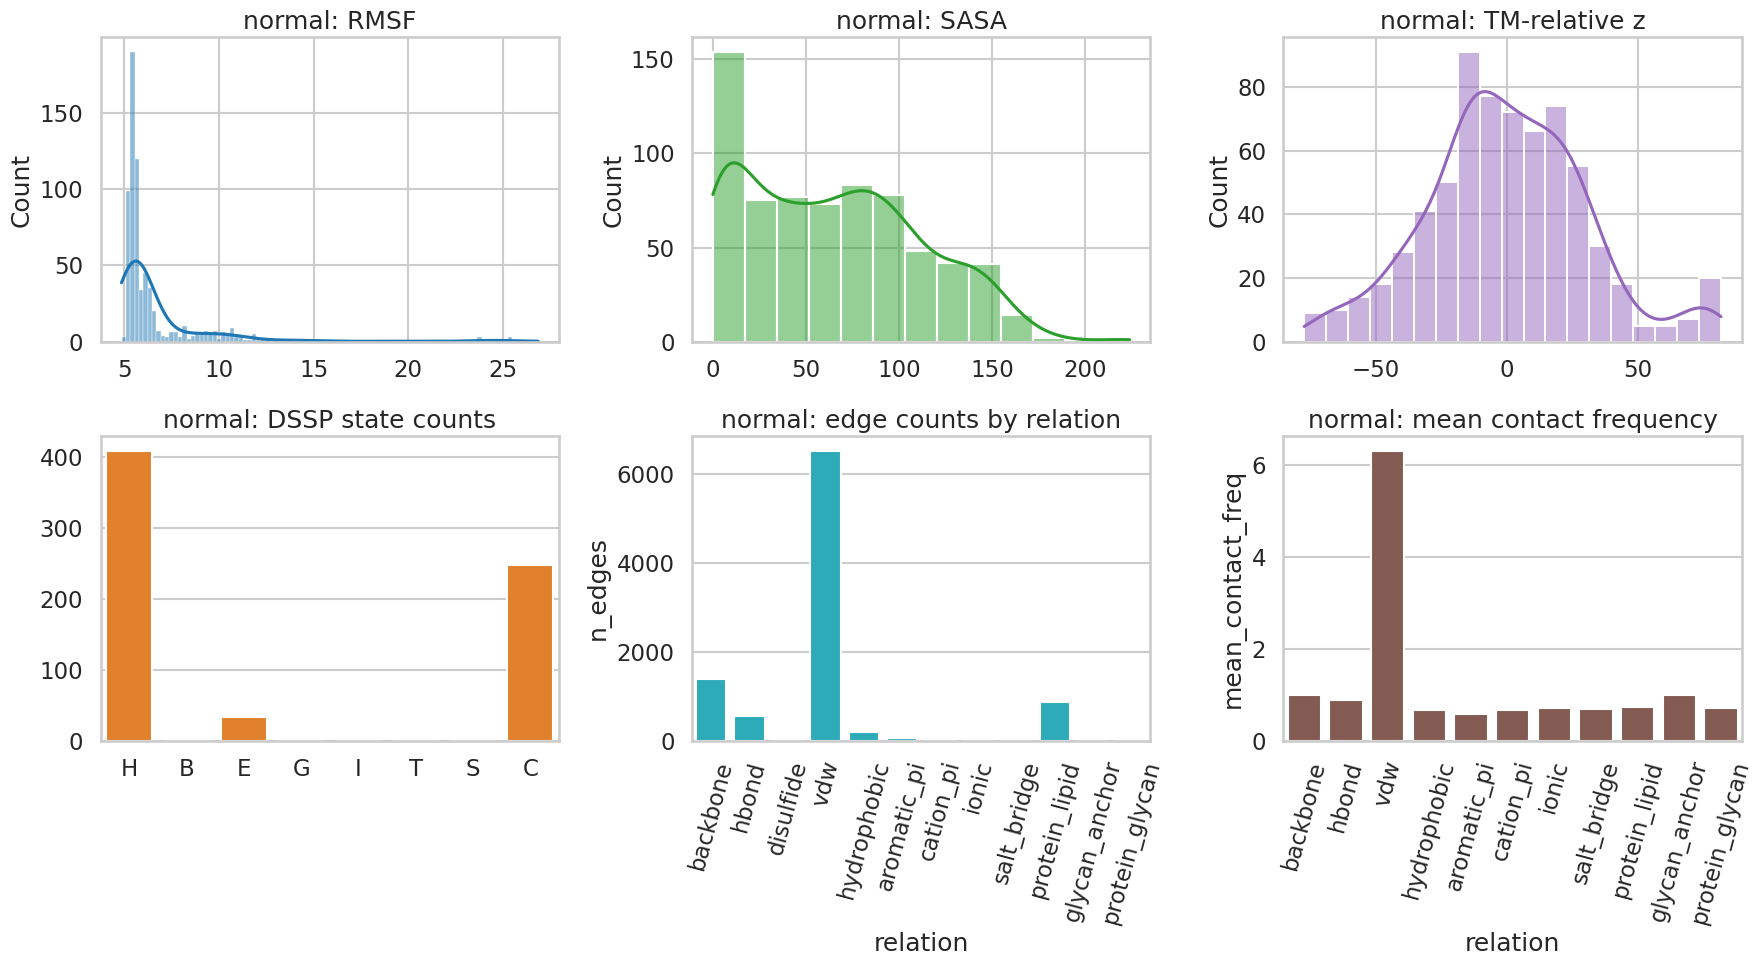

QC STATUS [normal] = WARN
  severity               check  \
0     WARN  contact_freq_range   

                                             message condition  
0  1 relation types outside expected mean contact...    normal  
----------------------------------------------------------------------------------------------------


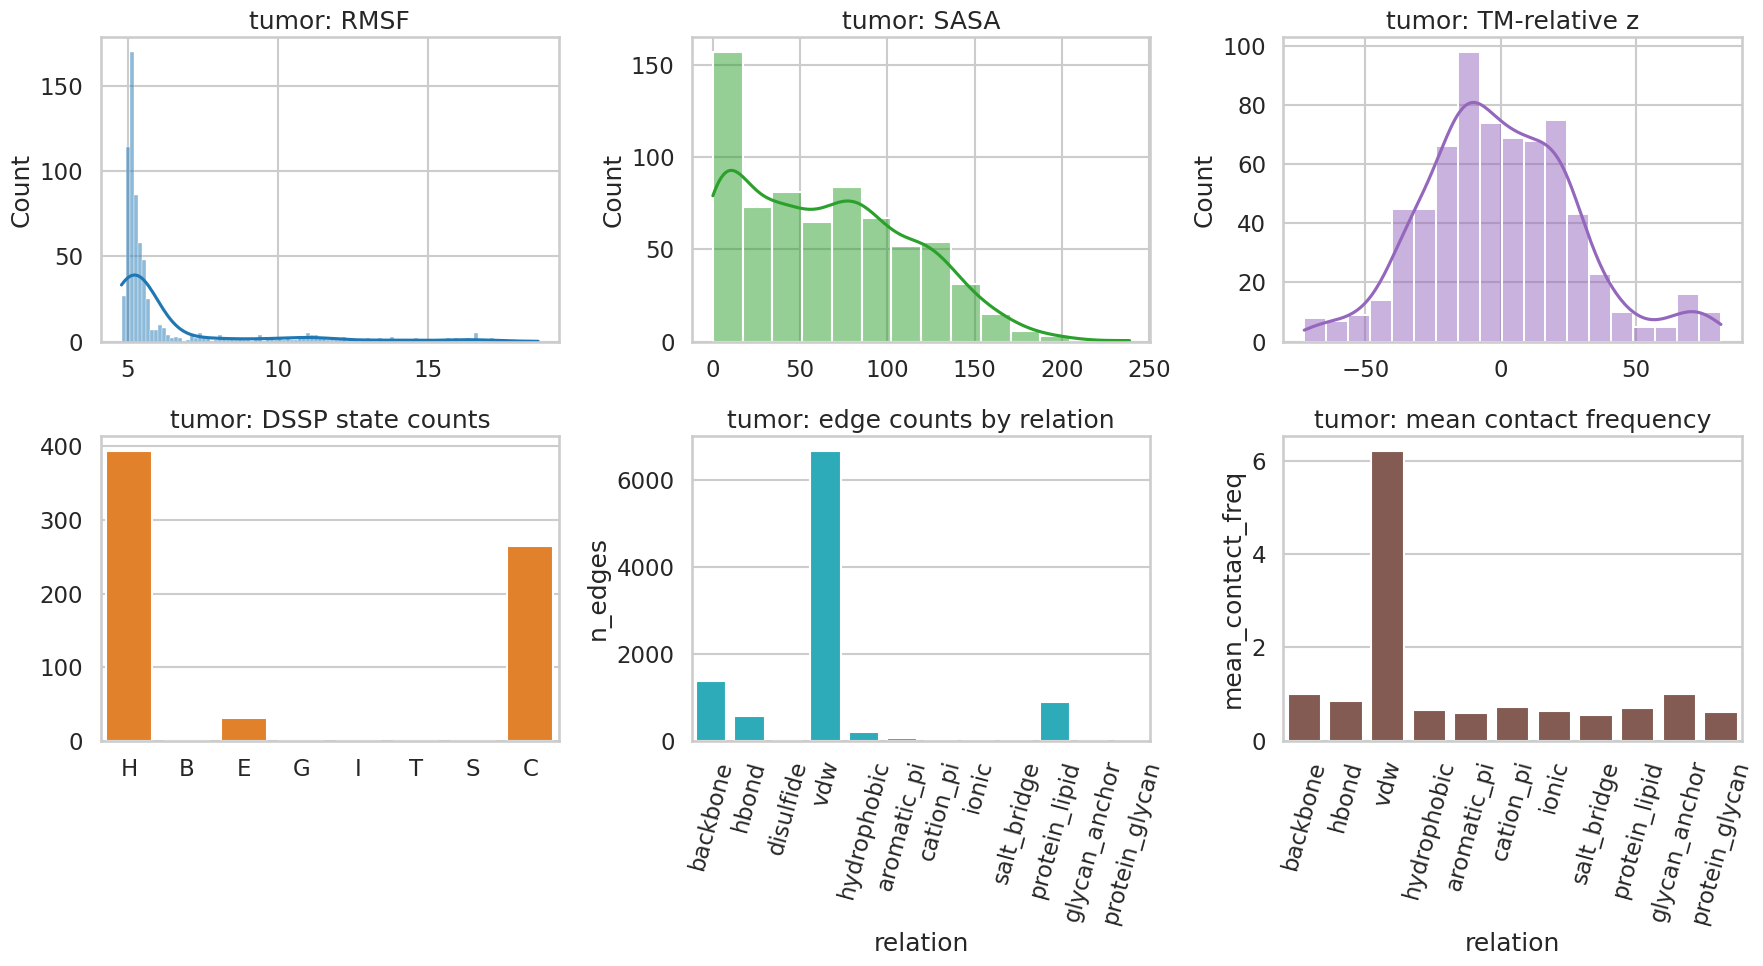

QC STATUS [tumor] = WARN
  severity               check  \
0     WARN  contact_freq_range   

                                             message condition  
0  1 relation types outside expected mean contact...     tumor  
----------------------------------------------------------------------------------------------------
DATASET QC STATUS = WARN
  condition  protein_nodes  lipid_nodes  glycan_nodes  protein_nan_fraction  lipid_nan_fraction  glycan_nan_fraction  rmsf_mean  rmsf_std  sasa_mean   sasa_std  tm_relative_z_mean  tm_relative_z_std  coil_fraction  dssp_frac_H  dssp_frac_B  dssp_frac_E  dssp_frac_G  dssp_frac_I  dssp_frac_T  dssp_frac_S  dssp_frac_C
0    normal            690          800             2                   0.0                 0.0                  0.0   6.825137  3.263824  64.227318  47.618713            0.011886          30.490498       0.359420     0.592754          0.0     0.047826          0.0          0.0          0.0          0.0     0.359420
1     tumor   

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')
sns.set_style('whitegrid')


QC_THRESHOLDS = {
    'max_nan_fraction':              0.0,
    'min_nonempty_relation_types':   5,   # PATCH v5: +1 для backbone
    'max_disulfide_edges':           20,
    'max_aromatic_to_vdw_ratio':     0.75,
    'min_mean_contact_freq':         0.30,
    'max_mean_contact_freq':         1.00,
    'max_fraction_coil_dssp':        0.95,
    'min_protein_lipid_edges':       1,
}


def tensor_nan_fraction(x: Tensor) -> float:
    if x.numel() == 0:
        return 0.0
    return float(torch.isnan(x).sum().item() / x.numel())


def summarize_node_features(condition: str, bundle: dict):
    graph  = bundle['graph']
    prot   = graph['protein'].x.detach().cpu().numpy()
    schema = FEATURE_SCHEMA['protein']['blocks']

    # Строим offsets по блокам
    offsets = {}
    start = 0
    for b in schema:
        offsets[b['name']] = (start, start + b['dim'])
        start += b['dim']

    def block(name):
        s, e = offsets[name]
        return prot[:, s:e]

    dssp        = block('dssp_onehot')
    dssp_counts = dssp.sum(axis=0) if dssp.size > 0 else np.zeros(len(DSSP_STATES))
    dssp_total  = dssp_counts.sum() if dssp_counts.sum() > 0 else 1.0
    dssp_frac   = {state: float(cnt / dssp_total)
                   for state, cnt in zip(DSSP_STATES, dssp_counts)}

    summary = {
        'condition':            condition,
        'protein_nodes':        int(graph['protein'].num_nodes),
        'lipid_nodes':          int(graph['lipid'].num_nodes),
        'glycan_nodes':         int(graph['glycan'].num_nodes),
        'protein_nan_fraction': tensor_nan_fraction(graph['protein'].x),
        'lipid_nan_fraction':   tensor_nan_fraction(graph['lipid'].x),
        'glycan_nan_fraction':  tensor_nan_fraction(graph['glycan'].x),
        'rmsf_mean':            float(block('rmsf').mean())          if block('rmsf').size > 0          else 0.0,
        'rmsf_std':             float(block('rmsf').std())           if block('rmsf').size > 0          else 0.0,
        'sasa_mean':            float(block('sasa').mean())          if block('sasa').size > 0          else 0.0,
        'sasa_std':             float(block('sasa').std())           if block('sasa').size > 0          else 0.0,
        'tm_relative_z_mean':   float(block('tm_relative_z').mean()) if block('tm_relative_z').size > 0 else 0.0,
        'tm_relative_z_std':    float(block('tm_relative_z').std())  if block('tm_relative_z').size > 0 else 0.0,
        'coil_fraction':        float(dssp_frac.get('C', 0.0)),
    }
    for k, v in dssp_frac.items():
        summary[f'dssp_frac_{k}'] = v
    return summary, offsets


def summarize_edges(condition: str, bundle: dict) -> pd.DataFrame:
    graph = bundle['graph']
    rows  = []
    for edge_type in RELATION_TYPES:
        edge_index = graph[edge_type].edge_index
        edge_attr  = graph[edge_type].edge_attr
        rows.append({
            'condition':        condition,
            'edge_type':        '::'.join(str(x) for x in edge_type),
            'relation':         edge_type[1],
            'n_edges':          int(edge_index.shape[1]),
            'mean_contact_freq': float(edge_attr[:, 0].mean().item()) if edge_attr.numel() > 0 else 0.0,
            'mean_dist':         float(edge_attr[:, 1].mean().item()) if edge_attr.numel() > 0 else 0.0,
            'std_dist':          float(edge_attr[:, 2].mean().item()) if edge_attr.numel() > 0 else 0.0,
        })
    return pd.DataFrame(rows)


def evaluate_qc_rules(condition: str, node_summary: dict, edge_summary: pd.DataFrame):
    issues = []
    thr    = QC_THRESHOLDS

    # NaN во фичах
    for key in ['protein_nan_fraction', 'lipid_nan_fraction', 'glycan_nan_fraction']:
        if node_summary[key] > thr['max_nan_fraction']:
            issues.append({'severity': 'FAIL', 'check': key,
                           'message': f'{key}={node_summary[key]:.6f} > allowed'})

    # Достаточно непустых типов рёбер
    nonempty_rel = int((edge_summary['n_edges'] > 0).sum())
    if nonempty_rel < thr['min_nonempty_relation_types']:
        issues.append({'severity': 'FAIL', 'check': 'nonempty_relation_types',
                       'message': f'{nonempty_rel} < {thr["min_nonempty_relation_types"]}'})

    # Дисульфидные мосты
    disulfide_edges = int(edge_summary.loc[edge_summary['relation'] == 'disulfide', 'n_edges'].sum())
    if disulfide_edges > thr['max_disulfide_edges']:
        issues.append({'severity': 'WARN', 'check': 'disulfide_edges',
                       'message': f'{disulfide_edges} unusually high'})

    # Соотношение ароматических / vdw
    vdw_edges      = float(edge_summary.loc[edge_summary['relation'] == 'vdw',         'n_edges'].sum())
    aromatic_edges = float(edge_summary.loc[edge_summary['relation'] == 'aromatic_pi', 'n_edges'].sum())
    if vdw_edges > 0:
        ratio = aromatic_edges / vdw_edges
        if ratio > thr['max_aromatic_to_vdw_ratio']:
            issues.append({'severity': 'WARN', 'check': 'aromatic_to_vdw_ratio',
                           'message': f'{ratio:.3f} unusually high'})

    # DSSP coil fraction
    if node_summary['coil_fraction'] > thr['max_fraction_coil_dssp']:
        issues.append({'severity': 'WARN', 'check': 'coil_fraction',
                       'message': f"coil_fraction={node_summary['coil_fraction']:.3f} suggests DSSP/fallback issue"})

    # Protein-lipid рёбра
    pl_edges = int(edge_summary.loc[edge_summary['relation'] == 'protein_lipid', 'n_edges'].sum())
    if pl_edges < thr['min_protein_lipid_edges']:
        issues.append({'severity': 'WARN', 'check': 'protein_lipid_edges',
                       'message': 'No or too few protein-lipid edges'})

    # Диапазон contact frequency
    bad_freq = edge_summary[
        (edge_summary['n_edges'] > 0) &
        ((edge_summary['mean_contact_freq'] < thr['min_mean_contact_freq']) |
         (edge_summary['mean_contact_freq'] > thr['max_mean_contact_freq']))
    ]
    if len(bad_freq) > 0:
        issues.append({'severity': 'WARN', 'check': 'contact_freq_range',
                       'message': f'{len(bad_freq)} relation types outside expected mean contact frequency range'})

    status = ('FAIL' if any(x['severity'] == 'FAIL' for x in issues) else
              'WARN' if any(x['severity'] == 'WARN' for x in issues) else 'PASS')
    return status, issues


def plot_qc_panels(condition: str, bundle: dict, offsets: dict, edge_summary: pd.DataFrame):
    graph = bundle['graph']
    prot  = graph['protein'].x.detach().cpu().numpy()

    def block(name):
        s, e = offsets[name]
        return prot[:, s:e]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    sns.histplot(block('rmsf').ravel(),         kde=True, ax=axes[0], color='#1f77b4')
    axes[0].set_title(f'{condition}: RMSF')

    sns.histplot(block('sasa').ravel(),         kde=True, ax=axes[1], color='#2ca02c')
    axes[1].set_title(f'{condition}: SASA')

    sns.histplot(block('tm_relative_z').ravel(),kde=True, ax=axes[2], color='#9467bd')
    axes[2].set_title(f'{condition}: TM-relative z')

    dssp        = block('dssp_onehot')
    dssp_counts = dssp.sum(axis=0) if dssp.size > 0 else np.zeros(len(DSSP_STATES))
    sns.barplot(x=DSSP_STATES, y=dssp_counts, ax=axes[3], color='#ff7f0e')
    axes[3].set_title(f'{condition}: DSSP state counts')

    sns.barplot(data=edge_summary, x='relation', y='n_edges', ax=axes[4], color='#17becf')
    axes[4].tick_params(axis='x', rotation=75)
    axes[4].set_title(f'{condition}: edge counts by relation')

    freq_df = edge_summary[edge_summary['n_edges'] > 0].copy()
    sns.barplot(data=freq_df, x='relation', y='mean_contact_freq', ax=axes[5], color='#8c564b')
    axes[5].tick_params(axis='x', rotation=75)
    axes[5].set_title(f'{condition}: mean contact frequency')

    plt.tight_layout()
    fig_path = OUTPUT_DIR / f'{condition}_qc_panels.png'
    plt.savefig(fig_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return fig_path


def validate_graph(data: HeteroData) -> dict:
    report = {}
    for node_type in NODE_TYPES:
        x = data[node_type].x
        report[f'{node_type}_num_nodes']      = int(data[node_type].num_nodes)
        report[f'{node_type}_feature_shape']  = tuple(x.shape)
        report[f'{node_type}_has_nan']        = bool(torch.isnan(x).any().item()) if x.numel() > 0 else False
        report[f'{node_type}_has_inf']        = bool(torch.isinf(x).any().item()) if x.numel() > 0 else False
    for edge_type in RELATION_TYPES:
        edge_index = data[edge_type].edge_index
        edge_attr  = data[edge_type].edge_attr
        key        = '::'.join(str(x) for x in edge_type)
        report[f'{key}_num_edges']         = int(edge_index.shape[1])
        report[f'{key}_edge_attr_shape']   = tuple(edge_attr.shape)
        report[f'{key}_edge_index_valid']  = bool(edge_index.shape[0] == 2)
        report[f'{key}_edge_attr_valid']   = bool(edge_attr.ndim == 2 and edge_attr.shape[1] == len(EDGE_ATTR_NAMES))
    return report


def validate_cross_condition_compatibility(graph_bundle: dict) -> dict:
    conditions = list(graph_bundle.keys())
    result     = {'conditions': conditions, 'compatible': True, 'issues': []}
    if len(conditions) < 2:
        return result
    ref = graph_bundle[conditions[0]]['manifest']
    for condition in conditions[1:]:
        cur = graph_bundle[condition]['manifest']
        if ref['relation_types'] != cur['relation_types']:
            result['compatible'] = False
            result['issues'].append(f'relation_types mismatch: {conditions[0]} vs {condition}')
        for node_type in NODE_TYPES:
            if ref['feature_schema'][node_type]['feature_names'] != cur['feature_schema'][node_type]['feature_names']:
                result['compatible'] = False
                result['issues'].append(f'feature schema mismatch for {node_type}: {conditions[0]} vs {condition}')
            if ref['node_shapes'][node_type][1] != cur['node_shapes'][node_type][1]:
                result['compatible'] = False
                result['issues'].append(f'feature dim mismatch for {node_type}: {conditions[0]} vs {condition}')
    return result


# ── Запуск QC ─────────────────────────────────────────────────────────────────

QC_NODE_SUMMARIES = []
QC_EDGE_SUMMARIES = []
QC_ISSUES         = []
QC_STATUS         = {}
QC_PANEL_PATHS    = {}

for condition, bundle in GRAPH_BUNDLE.items():
    node_summary, offsets = summarize_node_features(condition, bundle)
    edge_summary          = summarize_edges(condition, bundle)
    status, issues        = evaluate_qc_rules(condition, node_summary, edge_summary)
    panel_path            = plot_qc_panels(condition, bundle, offsets, edge_summary)

    QC_NODE_SUMMARIES.append(node_summary)
    QC_EDGE_SUMMARIES.append(edge_summary)
    QC_STATUS[condition]     = status
    QC_PANEL_PATHS[condition] = str(panel_path)
    for issue in issues:
        issue['condition'] = condition
        QC_ISSUES.append(issue)

    print(f'QC STATUS [{condition}] = {status}')
    print(pd.DataFrame(issues) if issues else 'No QC issues detected.')
    print('-' * 100)

QC_NODE_SUMMARY_DF = pd.DataFrame(QC_NODE_SUMMARIES)
QC_EDGE_SUMMARY_DF = (pd.concat(QC_EDGE_SUMMARIES, ignore_index=True)
                      if QC_EDGE_SUMMARIES else pd.DataFrame())
QC_ISSUES_DF       = (pd.DataFrame(QC_ISSUES)
                      if QC_ISSUES else pd.DataFrame(columns=['condition','severity','check','message']))

dataset_status = ('FAIL' if any(v == 'FAIL' for v in QC_STATUS.values()) else
                  'WARN' if any(v == 'WARN' for v in QC_STATUS.values()) else 'PASS')

QC_STATUS_REPORT = {
    'conditions':    QC_STATUS,
    'dataset_status': dataset_status,
    'thresholds':    QC_THRESHOLDS,
    'panel_paths':   QC_PANEL_PATHS,
}

QC_NODE_SUMMARY_DF.to_csv(OUTPUT_DIR / 'qc_node_summary.csv',            index=False)
QC_EDGE_SUMMARY_DF.to_csv(OUTPUT_DIR / 'qc_edge_summary_detailed.csv',   index=False)
QC_ISSUES_DF.to_csv(      OUTPUT_DIR / 'qc_issues.csv',                   index=False)
with open(OUTPUT_DIR / 'qc_status.json', 'w', encoding='utf-8') as f:
    json.dump(QC_STATUS_REPORT, f, indent=2, ensure_ascii=False)

print('DATASET QC STATUS =', dataset_status)
print(QC_NODE_SUMMARY_DF.to_string())
print(QC_EDGE_SUMMARY_DF.head().to_string())
print(QC_ISSUES_DF.to_string())

# ── Валидация графов ──────────────────────────────────────────────────────────

VALIDATION_REPORTS = {}
for condition, bundle in GRAPH_BUNDLE.items():
    report = validate_graph(bundle['graph'])
    VALIDATION_REPORTS[condition] = report
    print(f'Validation: {condition}')
    print(pd.Series(report).to_string())
    print(summarize_edges(condition, bundle).to_string())
    print('-' * 80)

CROSS_CONDITION_REPORT = validate_cross_condition_compatibility(GRAPH_BUNDLE)
print('Cross-condition compatibility:')
print(json.dumps(CROSS_CONDITION_REPORT, indent=2, ensure_ascii=False))

if not CROSS_CONDITION_REPORT['compatible']:
    raise RuntimeError('Cross-condition schema compatibility failed. Fix before saving.')

# Единая сводная таблица рёбер (используем уже накопленный QC_EDGE_SUMMARY_DF)
QC_EDGE_SUMMARY_DF.to_csv(OUTPUT_DIR / 'qc_edge_summary.csv', index=False)

## 11b. FILE_MAP — единый реестр имён экспортируемых файлов

Единый источник истины для имён файлов Phase3A → Phase3B.  
QC-проверка наличия файлов. Экспорт `alignment_result.json`.

In [ ]:
# =====================================================================
# CELL 3A-FMAP  ·  FILE_MAP — единый реестр всех экспортируемых файлов
#                  (вставить ПЕРЕД ячейкой экспорта Cell 12)
# =====================================================================
# Этот словарь является источником истины для имён файлов.
# Phase3B читает файлы ТОЛЬКО через EXPECTED_EXPORT_FILES
# и должен быть приведён в соответствие с этим словарём.
# =====================================================================

FILE_MAP: dict = {}

for cond in UNIVERSES:
    c = str(cond).lower()
    FILE_MAP[cond] = dict(
        # ── основные таблицы ──────────────────────────────────────────
        residue_table            = f"residue_table_{c}.csv",
        protein_contact_edges    = f"protein_contact_edges_{c}.csv",
        protein_contact_edges_ud = f"protein_contact_edges_undirected_{c}.csv",
        lipid_nodes              = f"lipid_nodes_{c}.csv",
        glycan_nodes             = f"glycan_nodes_{c}.csv",
        # ── новые (Notebook update) ────────────────────────────────────
        nonprotein_nodes         = f"nonprotein_nodes_{c}.csv",
        np_contact_edges         = f"np_contact_edges_{c}.csv",
        # ── PyG + гетерограф ──────────────────────────────────────────
        heterograph              = f"heterograph_{c}.pt",
        heterograph_norm         = f"heterograph_norm_{c}.pt",
        pos3d                    = f"pos3d_{c}.json",
        # ── per-frame (Cell 11b) ──────────────────────────────────────
        frame_features           = f"perframe/{c}/frame_features_{c}.csv",
        pyg_graphs               = f"perframe/{c}/pyg_graphs_{c}.pt",
        # ── per-frame parquet (Cell 3A-PERFRAME) ─────────────────────
        contact_edges_perframe   = f"contact_edges_perframe_{c}.parquet",
    )

# ── общие файлы ────────────────────────────────────────────────────────
FILE_MAP["_common"] = dict(
    manifest         = "phase3a_manifest.json",
    config           = "config.yaml",
    edge_semantics   = "edge_semantics.json",
    alignment_result = "alignment_result.json",   # новый
)

# ── QC-вывод на экран ─────────────────────────────────────────────────
print("=" * 60)
print("FILE_MAP  (Phase3A → Phase3B canonical file names)")
print("=" * 60)
for cond, fmap in FILE_MAP.items():
    print(f"\n  [{cond}]")
    for key, fname in fmap.items():
        full = OUTPUT_DIR / fname
        status = "✓" if full.exists() else "·"
        print(f"    {status}  {key:32s}  {fname}")

# ── Сохранить alignment_result ────────────────────────────────────────
import json
aln_path = OUTPUT_DIR / FILE_MAP["_common"]["alignment_result"]
with open(aln_path, "w", encoding="utf-8") as f:
    json.dump(ALIGNMENT_RESULT, f, indent=2, ensure_ascii=False)
print(f"\n[FMAP] alignment_result.json → {aln_path}")


FILE_MAP  (Phase3A → Phase3B canonical file names)

  [normal]
    ·  residue_table                     residue_table_normal.csv
    ·  protein_contact_edges             protein_contact_edges_normal.csv
    ·  protein_contact_edges_ud          protein_contact_edges_undirected_normal.csv
    ·  lipid_nodes                       lipid_nodes_normal.csv
    ·  glycan_nodes                      glycan_nodes_normal.csv
    ·  nonprotein_nodes                  nonprotein_nodes_normal.csv
    ·  np_contact_edges                  np_contact_edges_normal.csv
    ·  heterograph                       heterograph_normal.pt
    ·  heterograph_norm                  heterograph_norm_normal.pt
    ·  pos3d                             pos3d_normal.json
    ·  frame_features                    perframe/normal/frame_features_normal.csv
    ·  pyg_graphs                        perframe/normal/pyg_graphs_normal.pt
    ·  contact_edges_perframe            contact_edges_perframe_normal.parquet

  [tumor]
    

## 11. Сохранение

In [ ]:
DATASET_MANIFEST = {
    'graph_schema_version': GRAPH_SCHEMA_VERSION,
    'conditions':           list(GRAPH_BUNDLE.keys()),
    'relation_types':       [list(x) for x in RELATION_TYPES],
    'edge_attr_names':      EDGE_ATTR_NAMES,
    'feature_schema': {
        node_type: {
            'blocks':         FEATURE_SCHEMA[node_type]['blocks'],
            'feature_names':  flatten_feature_names(FEATURE_SCHEMA[node_type]['blocks'])
        } for node_type in FEATURE_SCHEMA
    },
    'feature_calc_params':           FEATURE_CALC_PARAMS,
    'edge_semantics':                EDGE_SEMANTICS,
    'cross_condition_compatibility': CROSS_CONDITION_REPORT,
    # PATCH v5.1
    'backbone_cutoff_A':   BACKBONE_MAX_CA_DIST_A,
    'glycan_template':     FA2G2S2_TEMPLATE,
    'regions_of_interest': {
        k: list(v) if v is not None else None
        for k, v in REGIONS_OF_INTEREST.items()
    },
    # FIX v5.2: offsets для слайсинга protein.x по блокам в 3D
    'feature_block_offsets': (lambda blocks: {
        b['name']: {
            'start': sum(bb['dim'] for bb in blocks[:i]),
            'end':   sum(bb['dim'] for bb in blocks[:i]) + b['dim'],
            'dim':   b['dim'],
        }
        for i, b in enumerate(blocks)
    })(FEATURE_SCHEMA['protein']['blocks']),
    # FIX v5.2: размерности всех типов узлов
    'node_feature_dims': {
        nt: sum(b['dim'] for b in FEATURE_SCHEMA[nt]['blocks'])
        for nt in FEATURE_SCHEMA
    },
    # FIX v5.2: edge_type → int-индекс для one-hot в 3D (15D = 3 attr + 12 types)
    'edge_type_index': {et[1]: i for i, et in enumerate(RELATION_TYPES)},
    'n_edge_types':    len(RELATION_TYPES),
}

# ── Сохранение per-condition файлов ──────────────────────────────────────────

# ── EXPORT_DIR определяется здесь на случай если Cell 12 ещё не запускалась
_exp = OUTPUT_DIR / 'phase3aexports'
_exp.mkdir(parents=True, exist_ok=True)

for condition, bundle in GRAPH_BUNDLE.items():
    graph_path      = _exp / f'heterograph_{condition}.pt'
    mapping_path    = _exp / f'resid_mapping_{condition}.json'
    manifest_path   = _exp / f'{condition}_manifest.json'
    lipid_path      = _exp / f'lipid_nodes_{condition}.csv'
    glycan_path     = _exp / f'glycan_nodes_{condition}.csv'
    validation_path = _exp / f'{condition}_validation.json'
    qc_path         = _exp / f'qc_edge_summary_{condition}.csv'

    torch.save(bundle['graph'], graph_path)

    with open(mapping_path, 'w', encoding='utf-8') as f:
        json.dump(bundle['resid_mapping'], f, indent=2, ensure_ascii=False)

    with open(manifest_path, 'w', encoding='utf-8') as f:
        json.dump(bundle['manifest'], f, indent=2, ensure_ascii=False)

    bundle['lipid_df'].to_csv(lipid_path, index=False)
    bundle['glycan_df'].to_csv(glycan_path, index=False)

    with open(validation_path, 'w', encoding='utf-8') as f:
        json.dump(VALIDATION_REPORTS[condition], f, indent=2, ensure_ascii=False)

    # QC_ALL может отсутствовать если QC-ячейка не выполнялась в текущей сессии
    if 'QC_ALL' in dir() and QC_ALL is not None:
        QC_ALL[QC_ALL['condition'] == condition].to_csv(qc_path, index=False)
    else:
        pd.DataFrame(bundle['manifest'].get('edge_summary', [])).to_csv(qc_path, index=False)
        print(f'  [WARN] QC_ALL not found — edge summary from manifest saved')

    print(f'Saved [{condition}]:')
    print(f'  graph        → {graph_path.name}')
    print(f'  mapping      → {mapping_path.name}')
    print(f'  manifest     → {manifest_path.name}')
    print(f'  lipid_nodes  → {lipid_path.name}')
    print(f'  glycan_nodes → {glycan_path.name}')
    print(f'  validation   → {validation_path.name}')
    print(f'  qc_summary   → {qc_path.name}')

# ── Сохранение dataset_manifest.json ─────────────────────────────────────────

manifest_out = _exp / 'dataset_manifest.json'
with open(manifest_out, 'w', encoding='utf-8') as f:
    json.dump(DATASET_MANIFEST, f, indent=2, ensure_ascii=False)
print(f'\nSaved dataset_manifest.json → {manifest_out}')


  [WARN] QC_ALL not found — edge summary from manifest saved
Saved [normal]:
  graph        → heterograph_normal.pt
  mapping      → resid_mapping_normal.json
  manifest     → normal_manifest.json
  lipid_nodes  → lipid_nodes_normal.csv
  glycan_nodes → glycan_nodes_normal.csv
  validation   → normal_validation.json
  qc_summary   → qc_edge_summary_normal.csv
  [WARN] QC_ALL not found — edge summary from manifest saved
Saved [tumor]:
  graph        → heterograph_tumor.pt
  mapping      → resid_mapping_tumor.json
  manifest     → tumor_manifest.json
  lipid_nodes  → lipid_nodes_tumor.csv
  glycan_nodes → glycan_nodes_tumor.csv
  validation   → tumor_validation.json
  qc_summary   → qc_edge_summary_tumor.csv

Saved dataset_manifest.json → /content/phase3a_outputs_scientific_v2/phase3aexports/dataset_manifest.json


In [ ]:
# CELL 12 — PATCH v5.2+CA — Phase3A Export → Phase3B
# Добавлены x_ca, y_ca, z_ca в residuetable для WANIA 3D layout.
# Все остальные части ячейки сохранены без изменений.

import datetime

EXPORT_DIR = OUTPUT_DIR / "phase3aexports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
print(f"EXPORT_DIR = {EXPORT_DIR}")

print("=" * 60)
print("PHASE3A EXPORT → Phase3B")
print("=" * 60)

# ──────────────────────────────────────────────────────────────
# PATCH: Cα coordinates (frame 0) для WANIA 3D layout
# ──────────────────────────────────────────────────────────────
CA_COORDS: Dict[str, Dict[int, list]] = {}

def build_ca_coords(u: mda.Universe) -> Dict[int, list]:
    """Извлекает XYZ Cα из кадра 0 траектории (static structural reference)."""
    u.trajectory[0]
    result = {}
    for a in u.select_atoms(CA_SELECTION):
        resid = int(a.resid)
        if resid not in result:
            result[resid] = [float(a.position[0]),
                              float(a.position[1]),
                              float(a.position[2])]
    return result

for condition, u in UNIVERSES.items():
    CA_COORDS[condition] = build_ca_coords(u)
    print(f"  {condition}: {len(CA_COORDS[condition])} Cα coords extracted (frame 0)")

# ──────────────────────────────────────────────────────────────
# aggregateproteincontacts — без изменений (FIX v5.2)
# ──────────────────────────────────────────────────────────────
def aggregate_protein_contacts(condition: str) -> pd.DataFrame:
    """
    Собирает protein-protein edges из CONTACTMAPS + backbone в единый DataFrame.
    edgetype_index — int, соответствует позиции в RELATION_TYPES (FIX v5.2).
    """
    etype_to_idx = {et[1]: i for i, et in enumerate(RELATION_TYPES)}
    rows = []
    for etype, payload in CONTACT_MAPS[condition].items():
        ei, ea = payload["edge_index"], payload["edge_attr"]
        if ei.shape[1] == 0:
            continue
        for k in range(ei.shape[1]):
            rows.append({
                "src":            int(ei[0, k]),
                "dst":            int(ei[1, k]),
                "edgetype":       etype,
                "edgetype_index": etype_to_idx.get(etype, -1),
                "contactfreq":    float(ea[k, 0]),
                "meandist":       float(ea[k, 1]),
                "stddist":        float(ea[k, 2]),
            })
    # backbone
    bb = BACKBONE_EDGES[condition]
    ei, ea = bb["edge_index"], bb["edge_attr"]
    for k in range(ei.shape[1]):
        rows.append({
            "src":            int(ei[0, k]),
            "dst":            int(ei[1, k]),
            "edgetype":       "backbone",
            "edgetype_index": etype_to_idx.get("backbone", -1),
            "contactfreq":    float(ea[k, 0]),
            "meandist":       float(ea[k, 1]),
            "stddist":        float(ea[k, 2]),
        })
    return pd.DataFrame(rows)


# ──────────────────────────────────────────────────────────────
# buildresiduetable — PATCH: добавлены x_ca, y_ca, z_ca
# ──────────────────────────────────────────────────────────────
def assign_region(resid: int) -> str:
    for name, bounds in REGIONS_OF_INTEREST.items():
        if bounds is None:
            continue
        lo, hi = bounds
        if lo <= resid <= hi:
            return name
    return "other"


def buildresiduetable(condition: str,
                      lipid_df: pd.DataFrame,
                      glycan_df: pd.DataFrame) -> pd.DataFrame:
    """
    Строит per-residue таблицу узлов для Phase3B.
    Колонки: nodeidx, resid, resname, aa1, region,
             isglycosylated, label, condition,
             x_ca, y_ca, z_ca  ← PATCH CA coords
    """
    residlist   = ESM_DATA[condition]["resid_list"]
    resnamelist = ESM_DATA[condition]["resname_list"]
    glycan_anchors = {int(row.anchor_resid) for _, row in glycan_df.iterrows()}
    ca_map = CA_COORDS.get(condition, {})

    rows = []
    for idx, (resid, resname) in enumerate(zip(residlist, resnamelist)):
        resid_int = int(resid)
        xyz = ca_map.get(resid_int, [0.0, 0.0, 0.0])
        rows.append({
            "nodeidx":        idx,
            "resid":          resid_int,
            "resname":        resname,
            "aa1":            AA3_TO_1.get(resname, "X"),
            "region":         assign_region(resid_int),
            "isglycosylated": int(resid_int in glycan_anchors),
            "label":          int(CONFIG[condition]["label"]),
            "condition":      condition,
            # PATCH v5.2+CA — структурные координаты для WANIA 3D
            "x_ca":           float(xyz[0]),
            "y_ca":           float(xyz[1]),
            "z_ca":           float(xyz[2]),
        })
    return pd.DataFrame(rows)


def buildresidmapping(condition: str,
                      lipid_df: pd.DataFrame,
                      glycan_df: pd.DataFrame) -> Dict[str, Any]:
    return {
        "condition":                 condition,
        "protein_index_to_resid":    {str(i): int(r) for i, r in enumerate(ESM_DATA[condition]["resid_list"])},
        "protein_index_to_resname":  {str(i): rn for i, rn in enumerate(ESM_DATA[condition]["resname_list"])},
        "protein_resid_to_index":    {str(r): i for i, r in enumerate(ESM_DATA[condition]["resid_list"])},
        "lipid_index_to_resid":      {str(int(row.lipidid)): int(row.resid) for _, row in lipid_df.iterrows()},
        "lipid_index_to_resname":    {str(int(row.lipidid)): row.resname for _, row in lipid_df.iterrows()},
        "glycan_index_to_anchor":    {str(int(row.glycanid)): int(row.anchor_resid) for _, row in glycan_df.iterrows()},
        "glycan_index_to_type":      {str(int(row.glycanid)): row.glycantype for _, row in glycan_df.iterrows()},
    }


# ──────────────────────────────────────────────────────────────
# Export loop — без изменений логики, добавлен pos3d JSON
# ──────────────────────────────────────────────────────────────
RESIDUE_TABLES: Dict[str, pd.DataFrame] = {}

for condition, u in UNIVERSES.items():
    bundle   = GRAPH_BUNDLE[condition]
    lipid_df = bundle["lipid_df"]
    glycan_df = bundle["glycan_df"]
    graph    = bundle["graph"]

    # 1. residuetable (теперь включает x_ca, y_ca, z_ca)
    residue_df = buildresiduetable(condition, lipid_df, glycan_df)
    RESIDUE_TABLES[condition] = residue_df
    residue_df.to_csv(EXPORT_DIR / f"residue_table_{condition}.csv", index=False)
    print(f"{condition} residuetable → residue_table_{condition}.csv  "
          f"{len(residue_df)} rows  "
          f"cols={list(residue_df.columns)}")

    # 2. protein contact edges + backbone
    contact_df = aggregate_protein_contacts(condition)
    contact_df.to_csv(EXPORT_DIR / f"protein_contact_edges_{condition}.csv", index=False)

    # PATCH v5.1: undirected CSV для networkx в Phase3B (src < dst)
    contact_df_undir = contact_df[contact_df["src"] < contact_df["dst"]].copy()
    contact_df_undir.to_csv(
        EXPORT_DIR / f"protein_contact_edges_undirected_{condition}.csv", index=False
    )
    print(f"{condition} contactedges_undir  {len(contact_df_undir)} rows directed {len(contact_df)}")
    print(f"{condition} contactedges → protein_contact_edges_{condition}.csv  "
          f"{len(contact_df)} rows, {contact_df['edgetype'].nunique()} types")

    # 3. lipid & glycan tables
    lipid_df.to_csv(EXPORT_DIR / f"lipid_nodes_{condition}.csv", index=False)
    glycan_df.to_csv(EXPORT_DIR / f"glycan_nodes_{condition}.csv", index=False)
    print(f"{condition} lipid/glycan saved")

    # 4. HeteroData snapshot
    torch.save(graph, EXPORT_DIR / f"heterograph_{condition}.pt")
    print(f"{condition} heterograph → heterograph_{condition}.pt")

    # 5. PATCH v5.1 — normalized heterograph для 3C/3D
    def normalize_hetero_features(g):
        import copy
        g2 = copy.deepcopy(g)
        x = g2["protein"].x.numpy().copy()
        start = 0
        for block in FEATURE_SCHEMA["protein"]["blocks"]:
            end = start + block["dim"]
            if block["name"] != "esm2":
                col = x[:, start:end]
                std = col.std(axis=0)
                std[std == 0] = 1.0
                x[:, start:end] = (col - col.mean(axis=0)) / std
            start = end
        g2["protein"].x = torch.tensor(x, dtype=torch.float32)
        # lipid z-score
        if g2["lipid"].x.numel() > 0:
            lx = g2["lipid"].x.numpy().copy()
            std = lx.std(axis=0); std[std == 0] = 1.0
            g2["lipid"].x = torch.tensor((lx - lx.mean(axis=0)) / std, dtype=torch.float32)
        return g2

    graph_norm = normalize_hetero_features(graph)
    torch.save(graph_norm, EXPORT_DIR / f"heterograph_norm_{condition}.pt")
    print(f"{condition} heterograph_norm → heterograph_norm_{condition}.pt")

    # 6. PATCH CA — pos3d JSON для WANIA Three.js
    import json
    pos3d_export = [
        {"resid": int(row["resid"]),
         "x": float(row["x_ca"]),
         "y": float(row["y_ca"]),
         "z": float(row["z_ca"])}
        for _, row in residue_df.iterrows()
    ]
    pos3d_path = EXPORT_DIR / f"pos3d_{condition}.json"
    pos3d_path.write_text(json.dumps(pos3d_export, indent=2))
    print(f"{condition} pos3d → pos3d_{condition}.json  ({len(pos3d_export)} residues)")


# ──────────────────────────────────────────────────────────────
# Manifest (FIX v5.2 — featureblockoffsets, nodefeaturedims)
# ──────────────────────────────────────────────────────────────
def featureblockoffsets(schema):
    offsets = {}
    for i, b in enumerate(schema):
        bname = b["name"]
        start = sum(schema[j]["dim"] for j in range(i))
        end   = start + b["dim"]
        offsets[bname] = {"start": start, "end": end, "dim": b["dim"]}
    return offsets

manifest = {
    "created":            datetime.datetime.now().isoformat(),
    "graph_schema_version": GRAPH_SCHEMA_VERSION,
    "conditions":         list(UNIVERSES.keys()),
    "relation_types":     [list(x) for x in RELATION_TYPES],
    "edge_attr_names":    EDGE_ATTR_NAMES,
    "feature_schema":     FEATURE_SCHEMA,
    "feature_calc_params": FEATURE_CALC_PARAMS,
    "edge_semantics":     EDGE_SEMANTICS,
    "feature_block_offsets": {
        nt: {b["name"]: {"start": sum(bb["dim"] for bb in FEATURE_SCHEMA[nt]["blocks"][:j]), "end": sum(bb["dim"] for bb in FEATURE_SCHEMA[nt]["blocks"][:j])+b["dim"], "dim": b["dim"]} for j, b in enumerate(FEATURE_SCHEMA[nt]["blocks"])}
        for nt in FEATURE_SCHEMA
    },
    "node_feature_dims": {
        nt: sum(b["dim"] for b in FEATURE_SCHEMA[nt]["blocks"])
        for nt in FEATURE_SCHEMA
    },
    "backbone_cutoff_A":  BACKBONE_MAX_CA_DIST_A,
    "glycan_template":    FA2G2S2_TEMPLATE,
    "regions_of_interest": {
        k: list(v) if v is not None else None
        for k, v in REGIONS_OF_INTEREST.items()
    },
    # PATCH CA — список экспортируемых файлов
    "export_files": {
        c: {
            "residuetable":        f"residue_table_{c}.csv",
            "contactedges":        f"protein_contact_edges_{c}.csv",
            "lipidnodes":          f"lipid_nodes_{c}.csv",
            "glycannodes":         f"glycan_nodes_{c}.csv",
            "heterograph":         f"heterograph_{c}.pt",
            "heterograph_norm":    f"heterograph_norm_{c}.pt",
            "contactedges_undir":  f"protein_contact_edges_undirected_{c}.csv",
            "pos3d":               f"pos3d_{c}.json",   # ← PATCH
        }
        for c in UNIVERSES
    },
}

# feature provenance for reproducibility
feature_prov = {
    "feature_schema": FEATURE_SCHEMA,
    "feature_calc_params": FEATURE_CALC_PARAMS,
    "edge_attr_names": EDGE_ATTR_NAMES,
    "relation_types": [list(x) for x in RELATION_TYPES],
}
with open(OUTPUT_DIR / "feature_provenance.json", "w", encoding="utf-8") as f:
    json.dump(feature_prov, f, indent=2, ensure_ascii=False)

p = EXPORT_DIR / "phase3a_manifest.json"
p.write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
print(f"\nManifest → {p.name}")

# ──────────────────────────────────────────────────────────────
# config.yaml для Phase3C
# ──────────────────────────────────────────────────────────────
import yaml

config_yaml = {
    "scenario":           "aggregated",
    "n_aug_train":        10,
    "aug_noise_sigma":    0.01,
    "tau_corr_frames":    None,
    "frame_frac":          FEATURE_CALC_PARAMS.get("frame_frac", 0.10),  # доля фреймов для Phase3C
    "random_state":       42,
    "min_contact_freq":   FEATURE_CALC_PARAMS["min_contact_frequency"],
    "epitope_resids":     list(REGIONS_OF_INTEREST["epitope"]),
    "ecd_resids":         list(REGIONS_OF_INTEREST["ECD"]),
    "protein_feature_dim": sum(b["dim"] for b in FEATURE_SCHEMA["protein"]["blocks"]),
    "lipid_feature_dim":  sum(b["dim"] for b in FEATURE_SCHEMA["lipid"]["blocks"]),
    "glycan_feature_dim": sum(b["dim"] for b in FEATURE_SCHEMA["glycan"]["blocks"]),
    "n_edge_types":       len(RELATION_TYPES),
    "edge_type_index":    {et[1]: i for i, et in enumerate(RELATION_TYPES)},
    "feature_block_offsets": {
        nt: {b["name"]: {"start": sum(bb["dim"] for bb in FEATURE_SCHEMA[nt]["blocks"][:j]), "end": sum(bb["dim"] for bb in FEATURE_SCHEMA[nt]["blocks"][:j])+b["dim"], "dim": b["dim"]} for j, b in enumerate(FEATURE_SCHEMA[nt]["blocks"])}
        for nt in FEATURE_SCHEMA
    },
    "glycan_template":    FA2G2S2_TEMPLATE,
    "backbone_cutoff_A":  BACKBONE_MAX_CA_DIST_A,
    "conditions":         list(UNIVERSES.keys()),
    "export_dir":         str(EXPORT_DIR),
}

config_path = EXPORT_DIR / "config.yaml"
config_path.write_text(
    yaml.dump(config_yaml, default_flow_style=False, allow_unicode=True)
)
print(f"config.yaml → {config_path}")

# ──────────────────────────────────────────────────────────────
# QC summary
# ──────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("EXPORT QC SUMMARY")
print("=" * 60)

for condition in UNIVERSES:
    tbl   = RESIDUE_TABLES[condition]
    graph = GRAPH_BUNDLE[condition]["graph"]
    print(f"\n{condition}")
    print(f"  protein nodes  {len(tbl)}")
    print(f"  lipid nodes    {graph['lipid'].num_nodes}")
    print(f"  glycan nodes   {graph['glycan'].num_nodes}")
    for et in graph.edge_types:
        n = graph[et].edge_index.shape[1]
        if n > 0:
            print(f"  {str(et):<50s} {n:6d} edges")
    nbb = BACKBONE_EDGES[condition]["edge_index"].shape[1]
    print(f"  backbone export          {nbb:6d} edges")
    # CA coord check
    n_ca_zero = (tbl["x_ca"] == 0.0).sum()
    print(f"  CA coords: {len(tbl) - n_ca_zero}/{len(tbl)} non-zero  "
          f"{'OK' if n_ca_zero == 0 else f'WARN {n_ca_zero} zeros'}")
    print("  regions:")
    for name, bounds in REGIONS_OF_INTEREST.items():
        if bounds is None:
            cnt = len(tbl)
        else:
            lo, hi = bounds
            cnt = int((tbl["resid"].between(lo, hi)).sum())
        print(f"    {name:<15s} {cnt} residues")

print(f"\nPhase3A v5.2+CA export complete → {EXPORT_DIR}")


EXPORT_DIR = /content/phase3a_outputs_scientific_v2/phase3aexports
PHASE3A EXPORT → Phase3B
  normal: 690 Cα coords extracted (frame 0)
  tumor: 690 Cα coords extracted (frame 0)
normal residuetable → residue_table_normal.csv  690 rows  cols=['nodeidx', 'resid', 'resname', 'aa1', 'region', 'isglycosylated', 'label', 'condition', 'x_ca', 'y_ca', 'z_ca']
normal contactedges_undir  4171 rows directed 8787
normal contactedges → protein_contact_edges_normal.csv  8787 rows, 8 types
normal lipid/glycan saved
normal heterograph → heterograph_normal.pt
normal heterograph_norm → heterograph_norm_normal.pt
normal pos3d → pos3d_normal.json  (690 residues)
tumor residuetable → residue_table_tumor.csv  690 rows  cols=['nodeidx', 'resid', 'resname', 'aa1', 'region', 'isglycosylated', 'label', 'condition', 'x_ca', 'y_ca', 'z_ca']
tumor contactedges_undir  4240 rows directed 8944
tumor contactedges → protein_contact_edges_tumor.csv  8944 rows, 8 types
tumor lipid/glycan saved
tumor heterograph → hetero

## 12b. Per-frame contact export (для временно́го RIN-анализа в Phase3B)

Экспортирует `contact_edges_perframe_{cond}.parquet` — контакты для каждого сохранённого фрейма.
**Требуется для Phase3B Step 9 (Temporal RIN).** Формат Parquet/Snappy (~100–400 MB на условие).

In [ ]:
# =====================================================================
# CELL 3A-PERFRAME  ·  Per-frame contact export for temporal analysis
# Phase3B Step 9 requires per-frame contacts in Parquet format.
# This cell runs AFTER the main contact calculation loop (Cell 7).
#
# Exports (per condition):
#   contact_edges_perframe_{cond}.parquet
#   Columns: frame, resid_i, resid_j, contact_type, distance
# =====================================================================

EXPORT_DIR = OUTPUT_DIR / 'phase3aexports'  # defined in Cell 12
EXPORT_DIR.mkdir(parents=True, exist_ok=True)




PERFRAME_STRIDE = 10
# How many frames to sample. 10 = every 10th frame (matching Phase3A stride).

PERFRAME_CUTOFFS = {
    "hbond":       4.0,   # Å  N/O donor-acceptor
    "saltbridge":  5.0,   # Å  charged groups
    "hydrophobic": 5.5,   # Å  Cβ–Cβ
    "all":         6.5,   # Å  generic Cα–Cα fallback
}

def _atom_contact_type(name_i: str, name_j: str, resname_i: str, resname_j: str) -> str:
    """Simple heuristic: classify contact type from atom/residue names."""
    hb_atoms  = {"N", "O", "ND1","ND2","NE","NE1","NE2","NZ","NH1","NH2",
                  "OD1","OD2","OE1","OE2","OG","OG1","OH","OT1","OT2"}
    chg_plus  = {"LYS","ARG","HIS"}
    chg_minus = {"ASP","GLU"}
    if name_i in hb_atoms and name_j in hb_atoms:
        return "hbond"
    if (resname_i in chg_plus  and resname_j in chg_minus) or \
       (resname_i in chg_minus and resname_j in chg_plus):
        return "saltbridge"
    return "hydrophobic"


for cond, u in UNIVERSES.items():
    protein = u.select_atoms("protein")
    residues = list(protein.residues)
    n_res = len(residues)

    frame_rows = []
    frames_to_use = list(range(0, len(u.trajectory), PERFRAME_STRIDE))

    for ts in tqdm(u.trajectory[::PERFRAME_STRIDE],
                   total=len(frames_to_use),
                   desc=f"[{cond}] per-frame contacts"):

        frame_idx = ts.frame
        pos = {res.resid: res.atoms.select_atoms("name CA").positions[0]
               for res in residues
               if len(res.atoms.select_atoms("name CA")) > 0}

        resids = sorted(pos.keys())
        for ii, ri in enumerate(resids):
            for rj in resids[ii+2:]:            # skip i±1 (bonded)
                d = np.linalg.norm(pos[ri] - pos[rj])
                if d > PERFRAME_CUTOFFS["all"]:
                    continue
                res_i = protein.residues[resids.index(ri)]
                res_j = protein.residues[resids.index(rj)]
                ctype = _atom_contact_type(
                    "CA", "CA", res_i.resname, res_j.resname
                )
                cutoff = PERFRAME_CUTOFFS.get(ctype, PERFRAME_CUTOFFS["all"])
                if d <= cutoff:
                    frame_rows.append({
                        "frame":       frame_idx,
                        "resid_i":     ri,
                        "resid_j":     rj,
                        "contact_type": ctype,
                        "distance":    round(float(d), 3),
                    })

    df_pf = pd.DataFrame(frame_rows, columns=["frame","resid_i","resid_j",
                                               "contact_type","distance"])
    out_path = EXPORT_DIR / f"contact_edges_perframe_{cond}.parquet"
    df_pf.to_parquet(out_path, index=False, compression="snappy")
    n_frames_actual = df_pf["frame"].nunique()
    print(f"[{cond}] perframe export: {len(df_pf):,} rows | "
          f"{n_frames_actual} frames | → {out_path.name}")
    del frame_rows, df_pf


[normal] per-frame contacts:   0%|          | 0/301 [00:00<?, ?it/s]

[normal] perframe export: 201,152 rows | 301 frames | → contact_edges_perframe_normal.parquet


[tumor] per-frame contacts:   0%|          | 0/301 [00:00<?, ?it/s]

[tumor] perframe export: 205,219 rows | 301 frames | → contact_edges_perframe_tumor.parquet


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  Выгрузка результатов на Яндекс Диск
#  Запускай вручную после завершения пайплайна.
# ══════════════════════════════════════════════════════════════════

if not YADISK_AVAILABLE:
    print('Яндекс Диск недоступен, выгрузка пропущена.')
else:
    EXPORT_DIR = OUTPUT_DIR / "phase3aexports"

    # ── Файлы из корня OUTPUT_DIR (QC, alignment, edge_semantics) ────────
    FILES_TO_UPLOAD = {}
    for fname in [
        'qc_status.json',
        'qc_node_summary.csv',
        'qc_edge_summary_detailed.csv',
        'qc_edge_summary.csv',
        'qc_issues.csv',
        'feature_provenance.json',
        'edge_semantics.json',
        'alignment_result.json',
    ]:
        p = OUTPUT_DIR / fname
        if p.exists():
            FILES_TO_UPLOAD[p] = f'{YADISK_RESULTS}/{fname}'

    # ── QC-панели (per-condition, в корне OUTPUT_DIR) ─────────────────────
    for cond in CONFIG:
        for fname in [f'{cond}_qc_panels.png']:
            p = OUTPUT_DIR / fname
            if p.exists():
                FILES_TO_UPLOAD[p] = f'{YADISK_RESULTS}/{fname}'

    # ── Все файлы из phase3aexports/ ─────────────────────────────────────
    if EXPORT_DIR.exists():
        for f in sorted(EXPORT_DIR.iterdir()):
            if f.is_file():
                FILES_TO_UPLOAD[f] = f'{YADISK_RESULTS}/phase3aexports/{f.name}'
        # ── perframe parquet (subdir) ─────────────────────────────────
        for f in sorted(EXPORT_DIR.glob('contact_edges_perframe_*.parquet')):
            FILES_TO_UPLOAD[f] = f'{YADISK_RESULTS}/phase3aexports/{f.name}'
        print(f'phase3aexports/: {sum(1 for f in EXPORT_DIR.iterdir() if f.is_file())} файлов')
    else:
        print('[WARN] phase3aexports/ не найдена — сначала запустите CELL 12')

    # ── Загрузка ──────────────────────────────────────────────────────────
    def _yadisk_makedirs(remote_dir: str, client):
        parts = remote_dir.strip('/').split('/')
        current = ''
        for part in parts:
            current = f'{current}/{part}' if current else part
            try:
                client.mkdir(current)
            except Exception:
                pass

    total = len(FILES_TO_UPLOAD)
    success, failed = 0, []

    with _yadisk.Client(token=YADISK_TOKEN) as client:
        for local_path, remote_path in FILES_TO_UPLOAD.items():
            local = Path(local_path)
            if not local.exists():
                print(f'  [skip] {local.name} — не найден')
                continue
            size_mb = local.stat().st_size / 1024**2
            remote_dir = '/'.join(remote_path.split('/')[:-1])
            _yadisk_makedirs(remote_dir, client)
            print(f'  ↑ {local.name}  {size_mb:.1f} MB  →  {remote_path}')
            t0 = time.time()
            try:
                client.upload(str(local), remote_path, overwrite=True)
                elapsed = time.time() - t0
                print(f'    [ok] {elapsed:.1f}s')
                success += 1
            except Exception as e:
                print(f'    [err] {str(e)[:80]}')
                failed.append(local.name)

    print(f'\nВыгружено: {success}/{total}')
    if failed:
        print(f'Ошибки: {", ".join(failed)}')

phase3aexports/: 33 файлов
  ↑ qc_status.json  0.0 MB  →  NAPI2B-ST-GNN/results/phase3A/qc_status.json
    [ok] 1.8s
  ↑ qc_node_summary.csv  0.0 MB  →  NAPI2B-ST-GNN/results/phase3A/qc_node_summary.csv
    [ok] 2.1s
  ↑ qc_edge_summary_detailed.csv  0.0 MB  →  NAPI2B-ST-GNN/results/phase3A/qc_edge_summary_detailed.csv
    [ok] 2.2s
  ↑ qc_edge_summary.csv  0.0 MB  →  NAPI2B-ST-GNN/results/phase3A/qc_edge_summary.csv
    [ok] 2.1s
  ↑ qc_issues.csv  0.0 MB  →  NAPI2B-ST-GNN/results/phase3A/qc_issues.csv
    [ok] 2.2s
  ↑ feature_provenance.json  0.0 MB  →  NAPI2B-ST-GNN/results/phase3A/feature_provenance.json
    [ok] 2.2s
  ↑ edge_semantics.json  0.0 MB  →  NAPI2B-ST-GNN/results/phase3A/edge_semantics.json
    [ok] 2.0s
  ↑ alignment_result.json  0.0 MB  →  NAPI2B-ST-GNN/results/phase3A/alignment_result.json
    [ok] 2.1s
  ↑ normal_qc_panels.png  0.4 MB  →  NAPI2B-ST-GNN/results/phase3A/normal_qc_panels.png
    [ok] 2.5s
  ↑ tumor_qc_panels.png  0.4 MB  →  NAPI2B-ST-GNN/results/phase